In [1]:
import os
import sys
import shutil

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml
from chroma import structure, plotting
from OpenMiChroM.CndbTools import cndbTools
import seaborn as sns
import pandas

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

plt.style.use("chroma.tex")

# nuclear bodies as fields

## chr1


In [2]:
conditions = ["complete", "nucleolus", "lamina", "control"]

NUM_REPLICAS = 32
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/4_analysis/energies/data"

In [3]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [4]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [5]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [9]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 1_000

### Comparing IC


In [7]:
IC = {}
types = {}

columns = [
    "step",
    "FENE",
    "angles",
    "self_avoidance",
    "types",
    "IC",
    "nucleolus",
    "nucleolus_exclusion",
    "spherical_confinement",
    "conic_confinement",
    "lamina",
]

col_to_exclude = {
    "nucleolus": ["lamina"],
    "lamina": ["nucleolus"],
    "complete": [],
    "control": ["nucleolus", "lamina"],
}

for condition in conditions:
    IC[condition] = []
    types[condition] = []

    for replica in range(1, NUM_REPLICAS + 1):

        df = pandas.read_csv(
            f"/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/3_sampling/{condition}/{replica}/energyComponents.txt",
            delimiter=",",
            skiprows=1,
            names=[
                x
                for x in columns
                if x not in col_to_exclude[condition]
            ],
        )
        IC[condition].extend(df["IC"].to_numpy())
        types[condition].extend(df["types"].to_numpy())

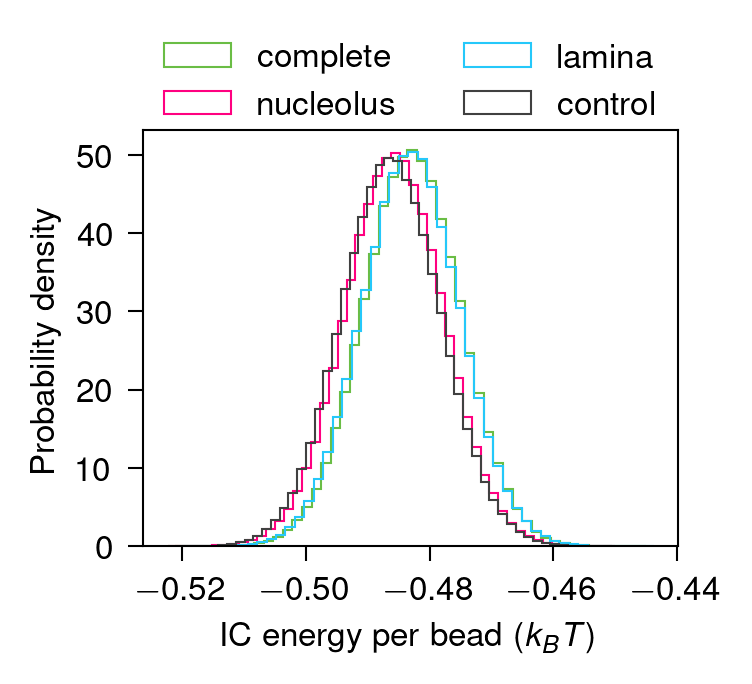

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in IC.keys():
    ax.hist(
        np.array(IC[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"IC energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

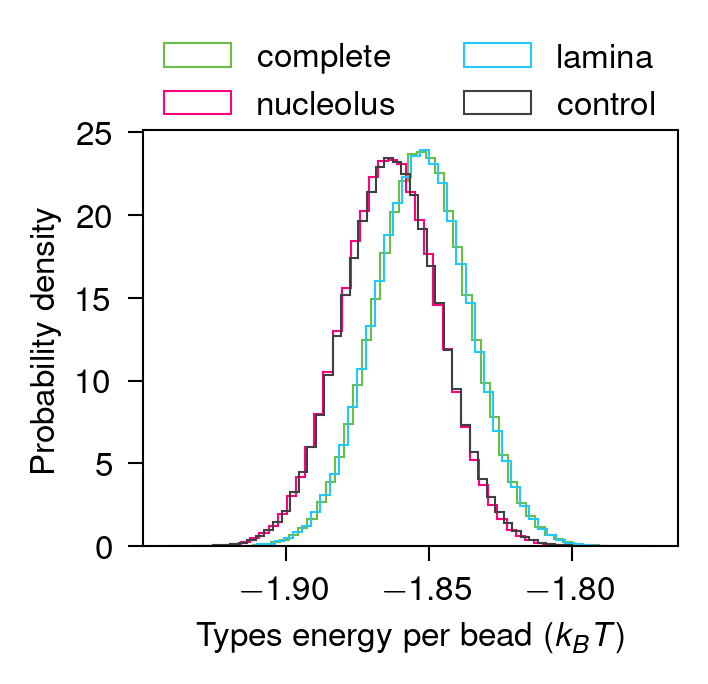

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in types.keys():
    ax.hist(
        np.array(types[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"Types energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

### Aggregate energy data


In [10]:
energies = {}
for condition in conditions:
    energies[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/contact-energies-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in energies[condition]:
                    energies[condition][key] = np.array([])
                energies[condition][key] = np.concatenate(
                    (
                        energies[condition][key],
                        f[key][()],
                    ),
                    axis=0,
                )
            energies[condition]["all"] = np.sum(
                np.array(
                    [
                        energies[condition][k]
                        for k in energies[condition]
                        if k != "all"
                    ]
                ),
                axis=0,
            )

In [11]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "w"
) as f:
    for condition in energies.keys():
        grp = f.create_group(condition)
        for key in energies[condition].keys():
            grp.create_dataset(key, data=energies[condition][key])

### Plotting contact energies


In [62]:
energies = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "r"
) as f:
    for condition in f.keys():
        energies[condition] = {}
        for key in f[condition].keys():
            energies[condition][key] = (
                f[condition][key][()] / NUM_BEADS
            )

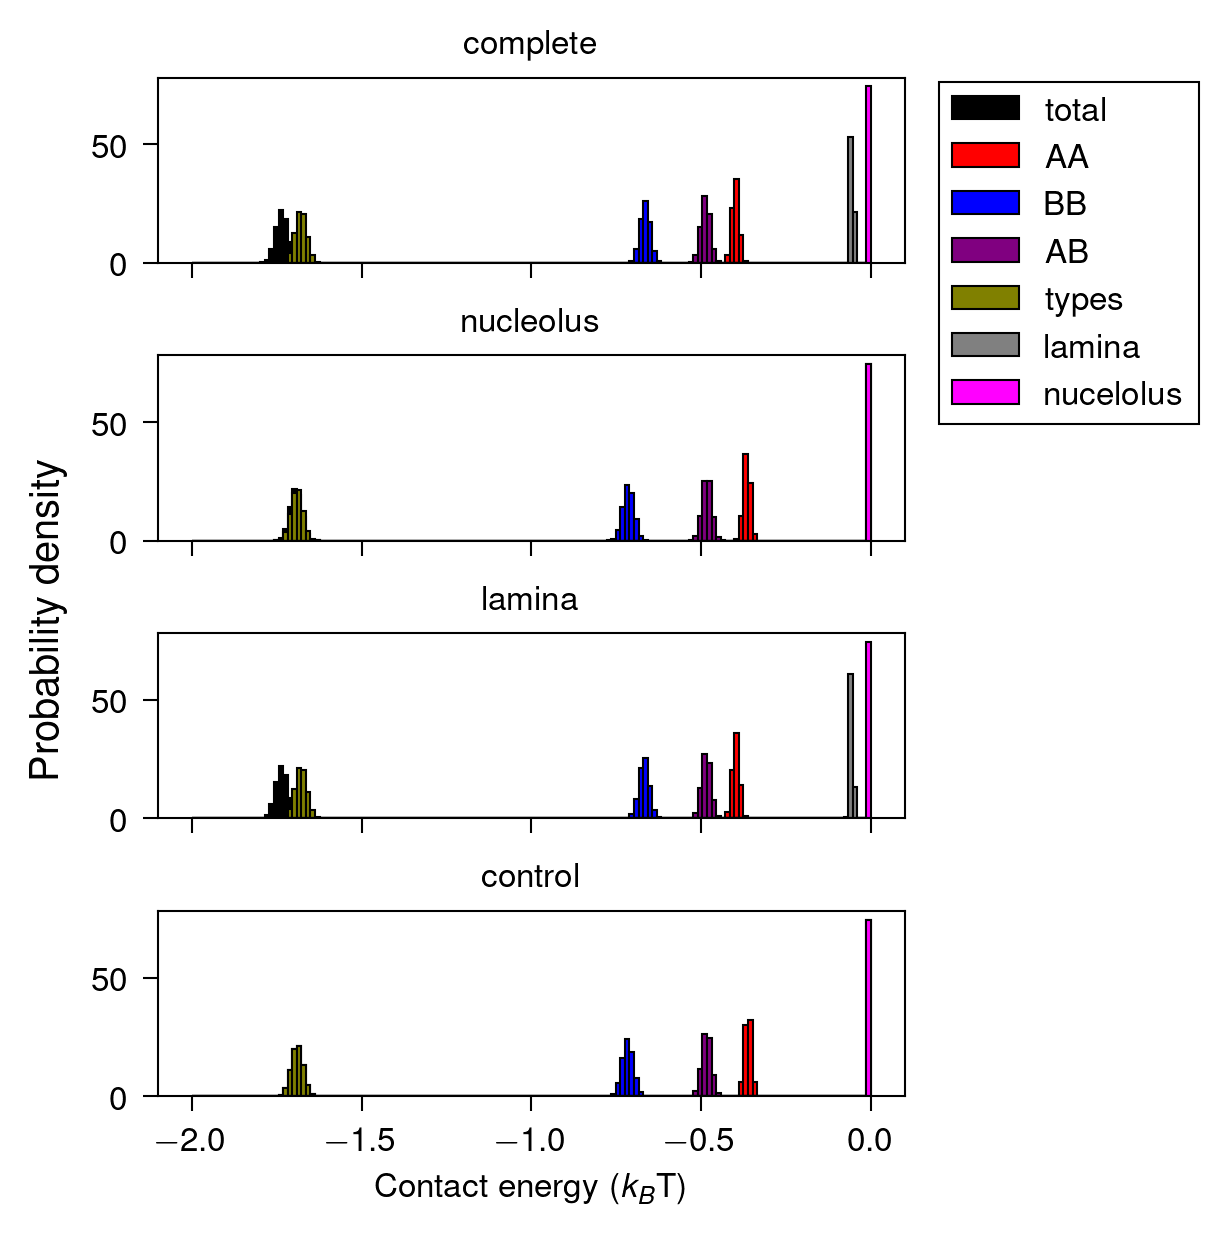

In [8]:
fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

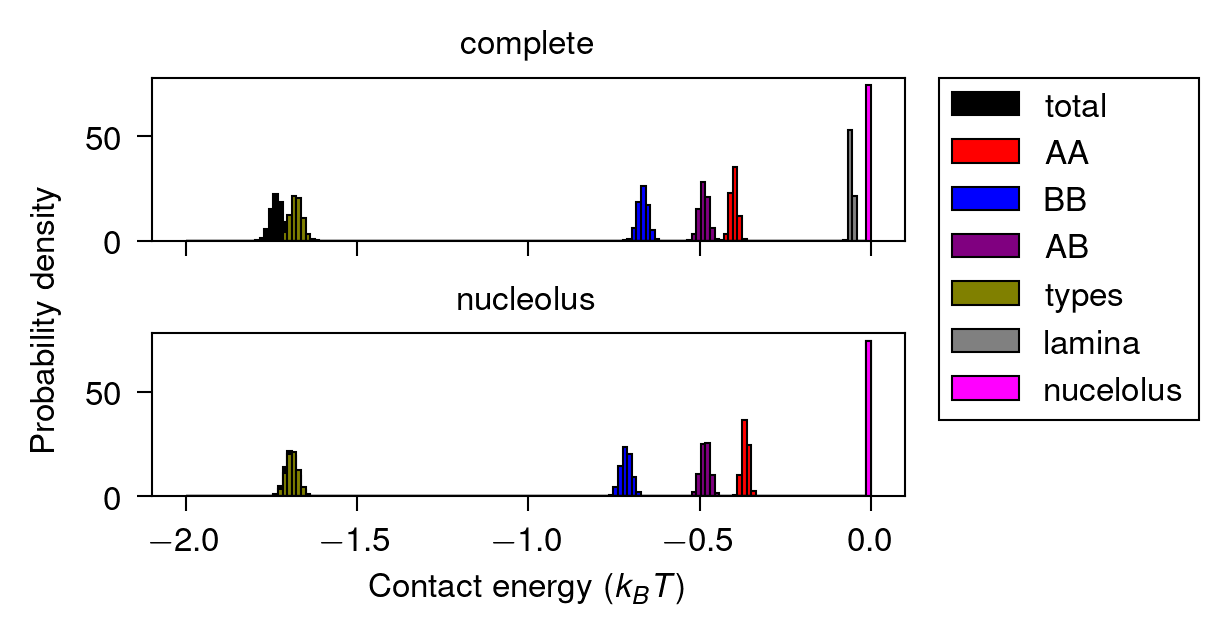

In [9]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

fig, ax = plt.subplots(
    len(chosen_conditions),
    1,
    figsize=(
        3,
        1 * len(chosen_conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(chosen_conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density", fontsize=8)
ax[-1].set_xlabel("Contact energy ($k_BT$)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.925),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

Text(0.5, 0.98, 'chr1')

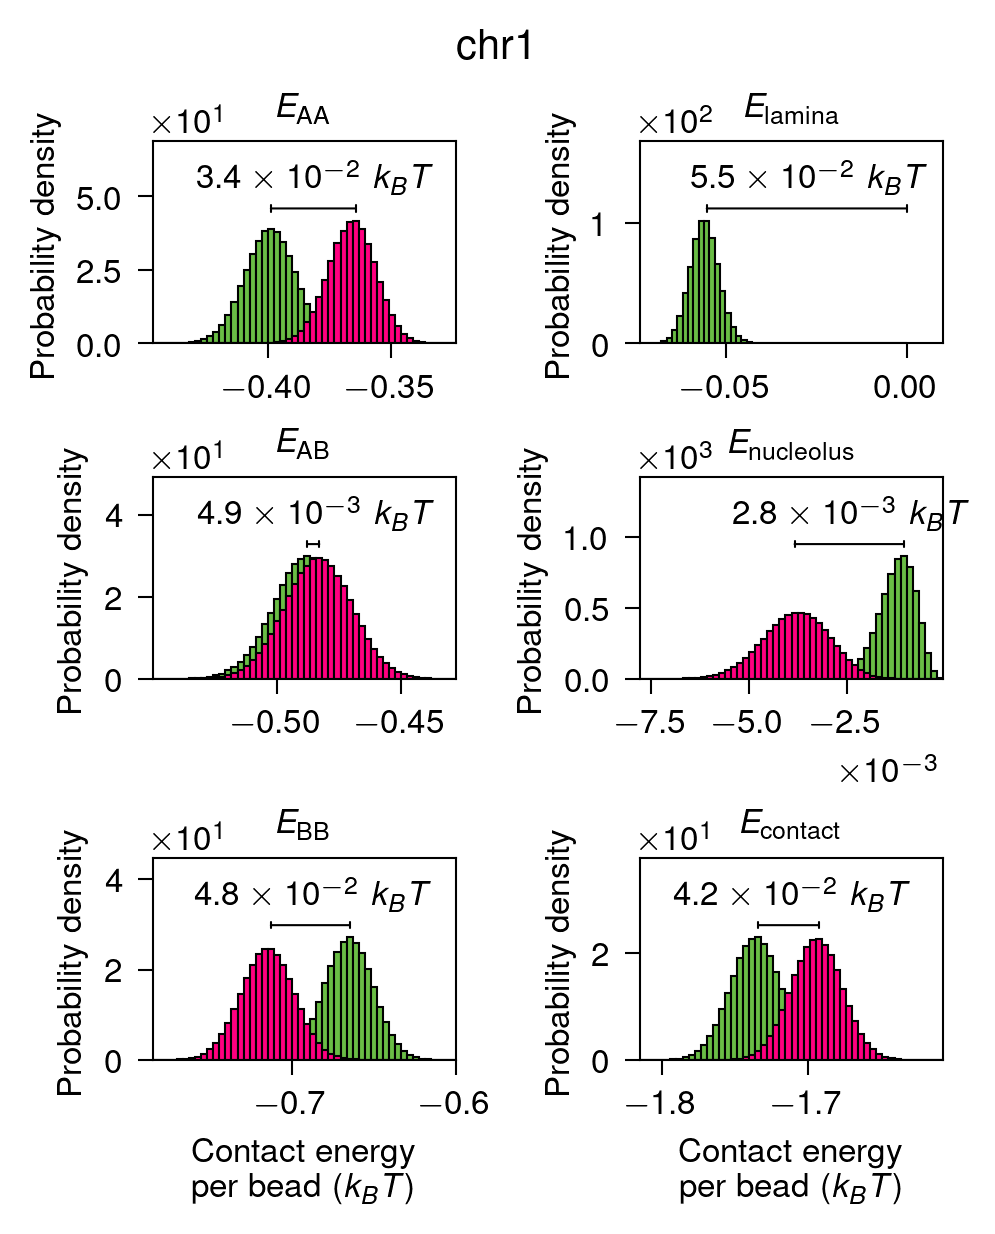

In [63]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = ["AA", "AB", "BB", "lamina", "nucleolus", "all"]
colors = ["red", "purple", "blue", "gray", "magenta", "black"]

fig, ax = plt.subplots(
    len(labels) // 2,
    2,
    figsize=(
        3.2,
        4.0,
    ),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 51

ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            density=True,
        )
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50 / NUM_BEADS

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = 1.1 * max(ymax)

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        # f"${int(energy_diff)}$ $k_BT$",
        f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax[i].set_title(
        f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    )
    ax[i].set_ylim(bottom=0, top=annot_y * 1.5)
    ax[i].set_xlim(vmin, vmax)
    ax[i].set_ylabel("Probability density", fontsize=8)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax[i].yaxis.set_major_formatter(formatter)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 1))
    ax[i].xaxis.set_major_formatter(formatter)

# ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
ax[-1].set_xlabel("Contact energy\nper bead ($k_BT$)",)
ax[2].set_xlabel("Contact energy\nper bead ($k_BT$)",)

# handles, labels = ax[0].get_legend_handles_labels()

fig.suptitle("chr1", fontsize=10)

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )

## chr17


In [44]:
conditions = ["complete", "nucleolus", "lamina", "control"]

NUM_REPLICAS = 32
NUM_BEADS = 1666
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/5_IMR-90_hg38_chr17/4_analysis/energies/data"

In [45]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [46]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [47]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [48]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

### Comparing IC


In [9]:
IC = {}
types = {}

columns = [
    "step",
    "FENE",
    "angles",
    "self_avoidance",
    "types",
    "IC",
    "nucleolus",
    "nucleolus_exclusion",
    "spherical_confinement",
    "conic_confinement",
    "lamina",
]

col_to_exclude = {
    "nucleolus": ["lamina"],
    "lamina": ["nucleolus"],
    "complete": [],
    "control": ["nucleolus", "lamina"],
}

for condition in conditions:
    IC[condition] = []
    types[condition] = []

    for replica in range(1, NUM_REPLICAS + 1):

        df = pandas.read_csv(
            f"/scratch/mm146/Polarization/5_IMR-90_hg38_chr17/3_sampling/{condition}/{replica}/energyComponents.txt",
            delimiter=",",
            skiprows=1,
            names=[
                x
                for x in columns
                if x not in col_to_exclude[condition]
            ],
        )
        IC[condition].extend(df["IC"].to_numpy())
        types[condition].extend(df["types"].to_numpy())

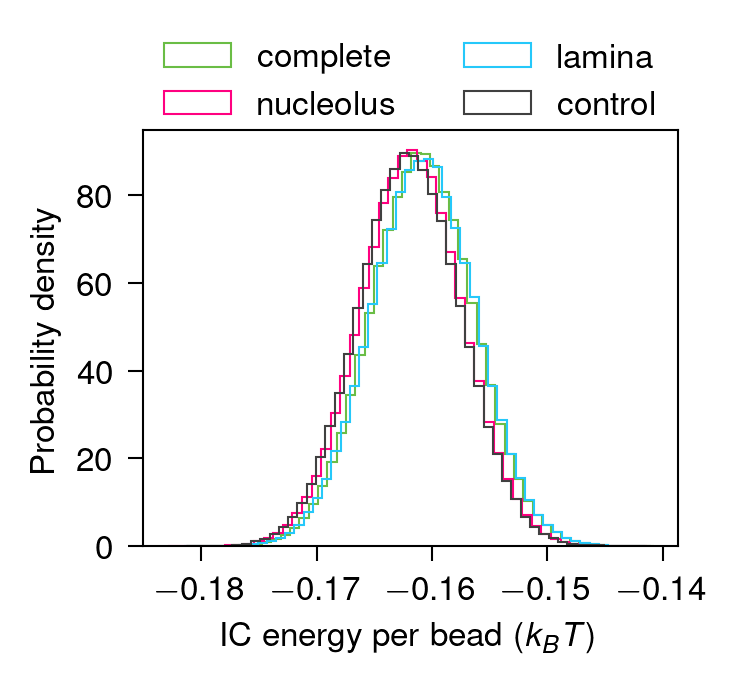

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in IC.keys():
    ax.hist(
        np.array(IC[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"IC energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

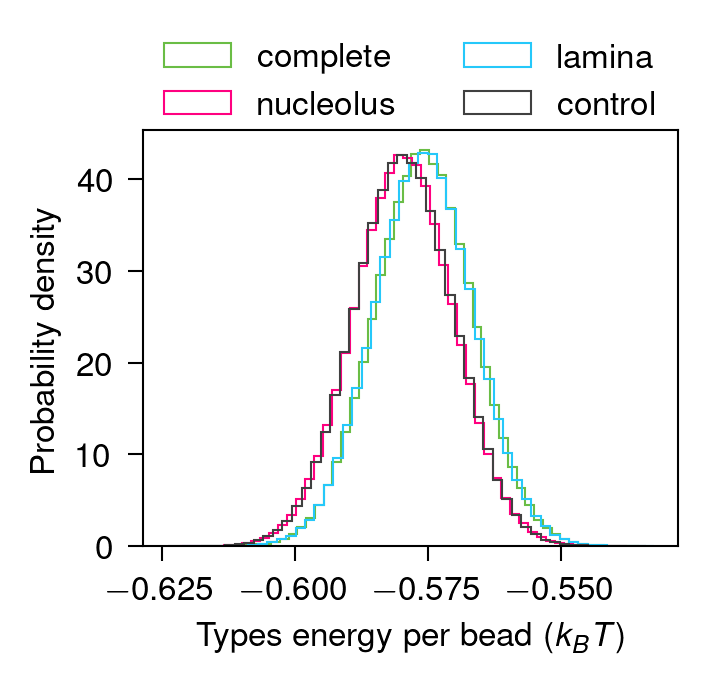

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in types.keys():
    ax.hist(
        np.array(types[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"Types energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

### Aggregate energy data


In [12]:
energies = {}
for condition in conditions:
    energies[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/contact-energies-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in energies[condition]:
                    energies[condition][key] = np.array([])
                energies[condition][key] = np.concatenate(
                    (
                        energies[condition][key],
                        f[key][()],
                    ),
                    axis=0,
                )
            energies[condition]["all"] = np.sum(
                np.array(
                    [
                        energies[condition][k]
                        for k in energies[condition]
                        if k != "all"
                    ]
                ),
                axis=0,
            )

In [13]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "w"
) as f:
    for condition in energies.keys():
        grp = f.create_group(condition)
        for key in energies[condition].keys():
            grp.create_dataset(key, data=energies[condition][key])

### Plotting contact energies


In [51]:
energies = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "r"
) as f:
    for condition in f.keys():
        energies[condition] = {}
        for key in f[condition].keys():
            energies[condition][key] = (
                f[condition][key][()] / NUM_BEADS
            )

In [ ]:
fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

In [ ]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

fig, ax = plt.subplots(
    len(chosen_conditions),
    1,
    figsize=(
        3,
        1 * len(chosen_conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(chosen_conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density", fontsize=8)
ax[-1].set_xlabel("Contact energy ($k_BT$)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.925),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

Text(0.5, 0.98, 'chr17')

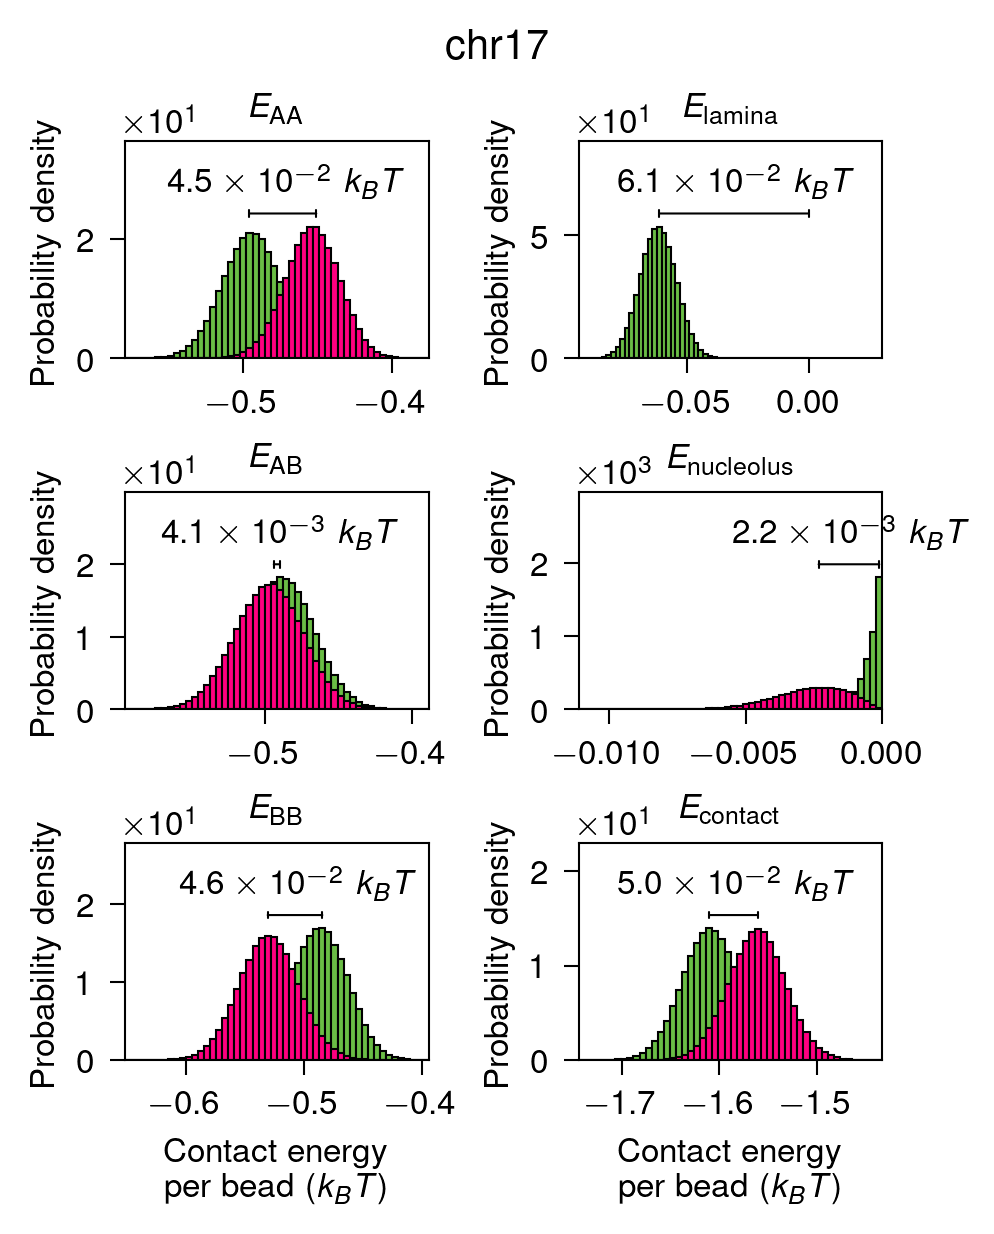

In [53]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = ["AA", "AB", "BB", "lamina", "nucleolus", "all"]
colors = ["red", "purple", "blue", "gray", "magenta", "black"]

fig, ax = plt.subplots(
    len(labels) // 2,
    2,
    figsize=(
        3.2,
        4.0,
    ),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 51

ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            density=True,
        )
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50 / NUM_BEADS

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = 1.1 * max(ymax)

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        # f"${int(energy_diff)}$ $k_BT$",
        f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax[i].set_title(
        f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    )
    ax[i].set_ylim(bottom=0, top=annot_y * 1.5)
    ax[i].set_xlim(vmin, vmax)
    ax[i].set_ylabel("Probability density", fontsize=8)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax[i].yaxis.set_major_formatter(formatter)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 1))
    ax[i].xaxis.set_major_formatter(formatter)

# ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
ax[-1].set_xlabel("Contact energy\nper bead ($k_BT$)",)
ax[2].set_xlabel("Contact energy\nper bead ($k_BT$)",)

# handles, labels = ax[0].get_legend_handles_labels()

fig.suptitle("chr17", fontsize=10)

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )

# nuclear bodies as beads

## finding bug in energies

In [14]:
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)

In [3]:
traj = cndbTools()

In [4]:
traj.load("/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/complete/1/nucleus_0.cndb")

Cndb file has 10000 frames, with 4980 beads and {b'A1', b'B3', b'B1', b'NA', b'B2', b'A2'} types 

In [6]:
lamina = cndbTools()
lamina.load("/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/complete/1/nucleus_1.cndb")


Cndb file has 10000 frames, with 126 beads and {b'LM'} types 

In [7]:
nucleolus = cndbTools()
nucleolus.load("/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/complete/1/nucleus_2.cndb")

Cndb file has 10000 frames, with 43 beads and {b'NC'} types 

In [8]:
positions = traj.xyz(frames=range(0, 10_000, 1000))

In [24]:
def confinement(r, rConf=35, eCutConf=10, r0Conf=0.93, kConf=21.94):
    deltaR = rConf - r
    return 0.5 * eCutConf * (1.0 + np.tanh(1.0 - (kConf * (deltaR - r0Conf))))

def nuclear_body_exclusion(
    r, epsilon=1, Ecut=4, r0=0.93, k_rep=21.94, nb_radius=1.5
):
    """
    Compute the smooth repulsive potential:
        0.5 * Ecut * (1 + tanh(1 - k_rep * (r - r0)))

    Parameters
    ----------
    r : float or np.ndarray
        Distance(s) between particles.
    epsilon : float
        Lennard-Jones epsilon-like scaling factor.
    Ecut : float
        Cutoff energy (will be scaled by epsilon).
    r0 : float
        Reference distance for the repulsion center.
    k_rep : float
        Steepness of the repulsive wall.

    Returns
    -------
    energy : float or np.ndarray
        Soft repulsive potential energy.
    """

    # Scale Ecut by epsilon
    Ecut_scaled = Ecut * epsilon

    # Repulsive soft potential
    energy = (
        0.5
        * Ecut_scaled
        * (1.0 + np.tanh(1.0 - (k_rep * ((r - nb_radius) - r0))))
    )

    return energy

(0.0, 0.1305800241176982)

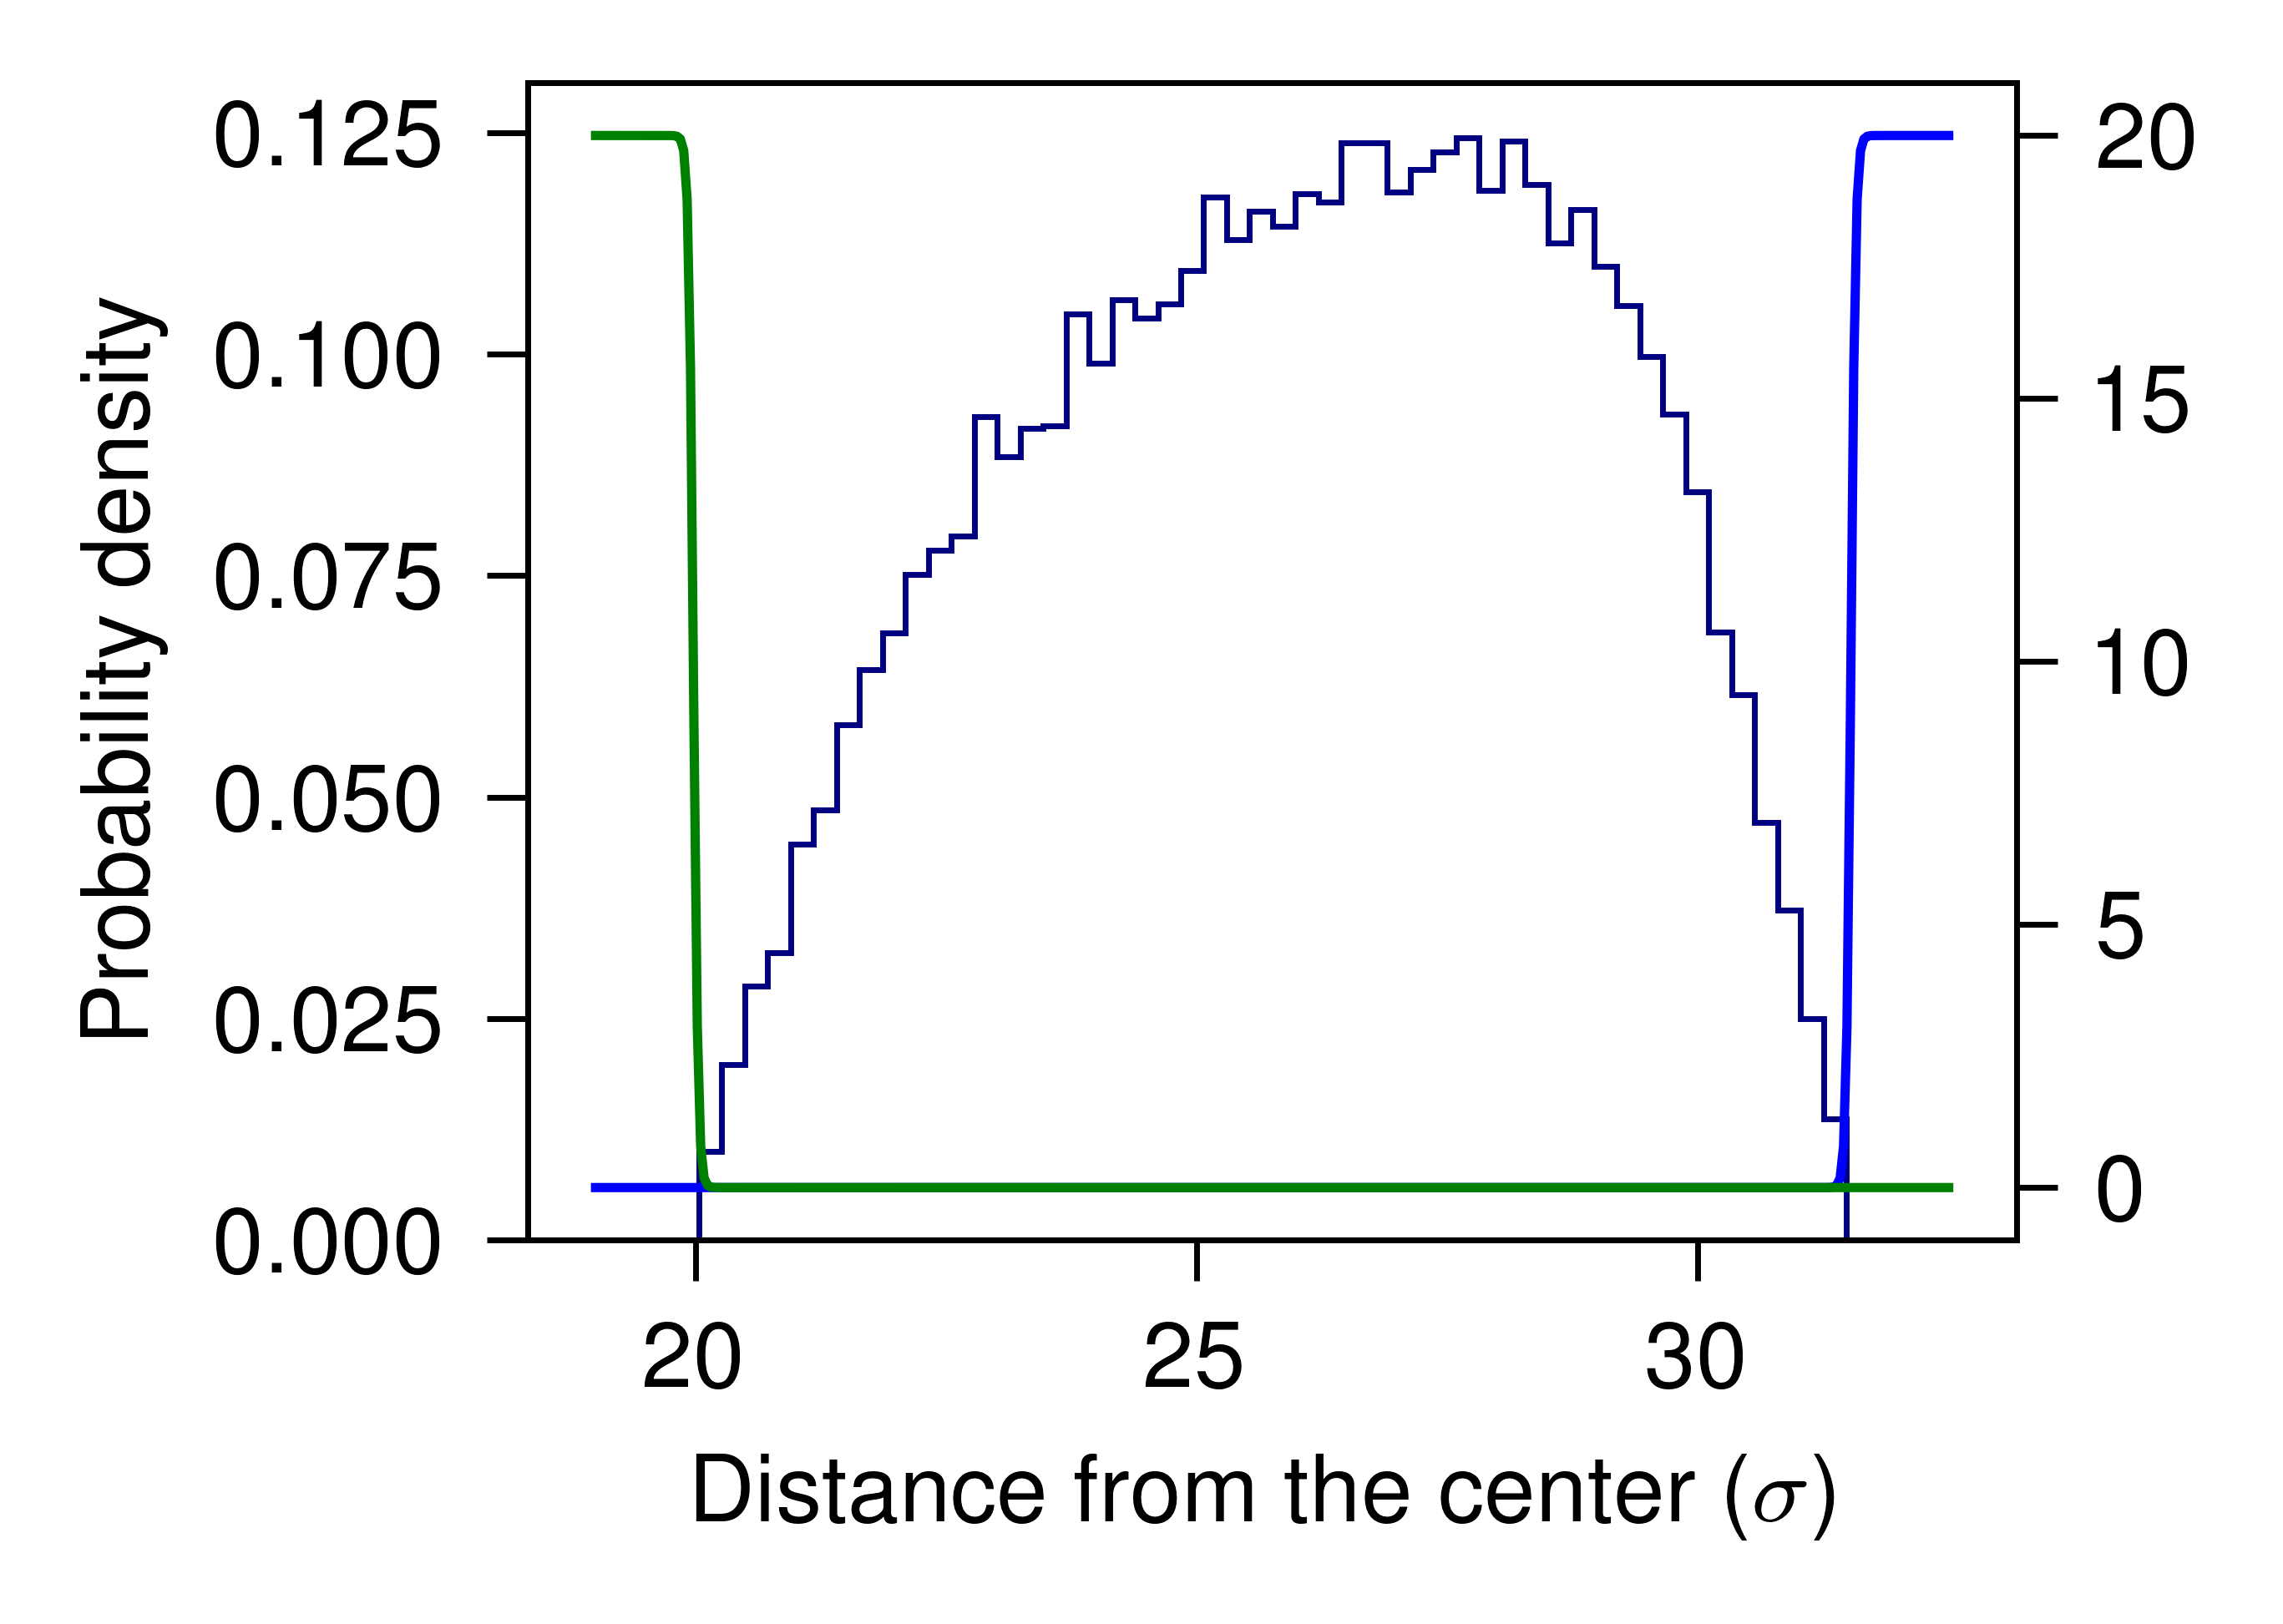

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

ax.hist(
    np.linalg.norm(positions, axis=-1).flatten(),
    bins=50,
    density=True,
    histtype="step",
)

ylim = ax.get_ylim()

# ax.vlines(NUCLEOLI_RADIUS, ylim[0], ylim[1], color="red", label="nucleolus radius")
# ax.vlines(NUCLEUS_RADIUS, ylim[0], ylim[1], color="black", label="nucleus radius")

ax.set_xlabel(r"Distance from the center ($\sigma$)")
ax.set_ylabel("Probability density")
# ax.legend(loc="upper right", frameon=False)  

ax2 = ax.twinx()
r = np.linspace(NUCLEOLI_RADIUS, NUCLEUS_RADIUS, 400)

lamina_excl = confinement(r, rConf=NUCLEUS_RADIUS, eCutConf=20, r0Conf=0.93, kConf=21.94)
nucleolus_excl = nuclear_body_exclusion(
    r, epsilon=1, Ecut=20, r0=0.93, k_rep=21.94, nb_radius=NUCLEOLI_RADIUS
)

ax2.plot(r, lamina_excl, color="blue", label="lamina exclusion")
ax2.plot(r, nucleolus_excl, color="green", label="nucleolus exclusion")

ax.set_ylim(ylim[0], ylim[1])

In [26]:
np.linalg.norm(positions, axis=-1).flatten().max()

31.481598840516924

In [27]:
# distance to the lamina

lamina_positions = lamina.xyz(frames=range(0, 10_000, 1000))

In [34]:
# check if lamina positions are all the same

distances_to_lamina = structure.compute_distances_trajectory(
    positions, lamina_positions
)

In [39]:
def contact(r, mu, rc, lim=1.0, epsilon=-1):
    return (
        epsilon
        * 0.5
        * (1 + np.tanh(mu * (rc - r)))
        * np.heaviside(r - lim, 1)
    )


In [41]:
def tanh_exclusion(r, epsilon=1, Ecut=4, r0=1, k_rep=20):
    """
    Compute the smooth repulsive potential:
        0.5 * Ecut * (1 + tanh(1 - k_rep * (r - r0)))

    Parameters
    ----------
    r : float or np.ndarray
        Distance(s) between particles.
    epsilon : float
        Lennard-Jones epsilon-like scaling factor.
    Ecut : float
        Cutoff energy (will be scaled by epsilon).
    r0 : float
        Reference distance for the repulsion center.
    k_rep : float
        Steepness of the repulsive wall.

    Returns
    -------
    energy : float or np.ndarray
        Soft repulsive potential energy.
    """

    # Scale Ecut by epsilon
    Ecut_scaled = Ecut * epsilon

    # Repulsive soft potential
    energy = (
        0.5 * Ecut_scaled * (1.0 + np.tanh(1.0 - (k_rep * (r - r0))))
    )

    return energy

(-0.4, 2.0)

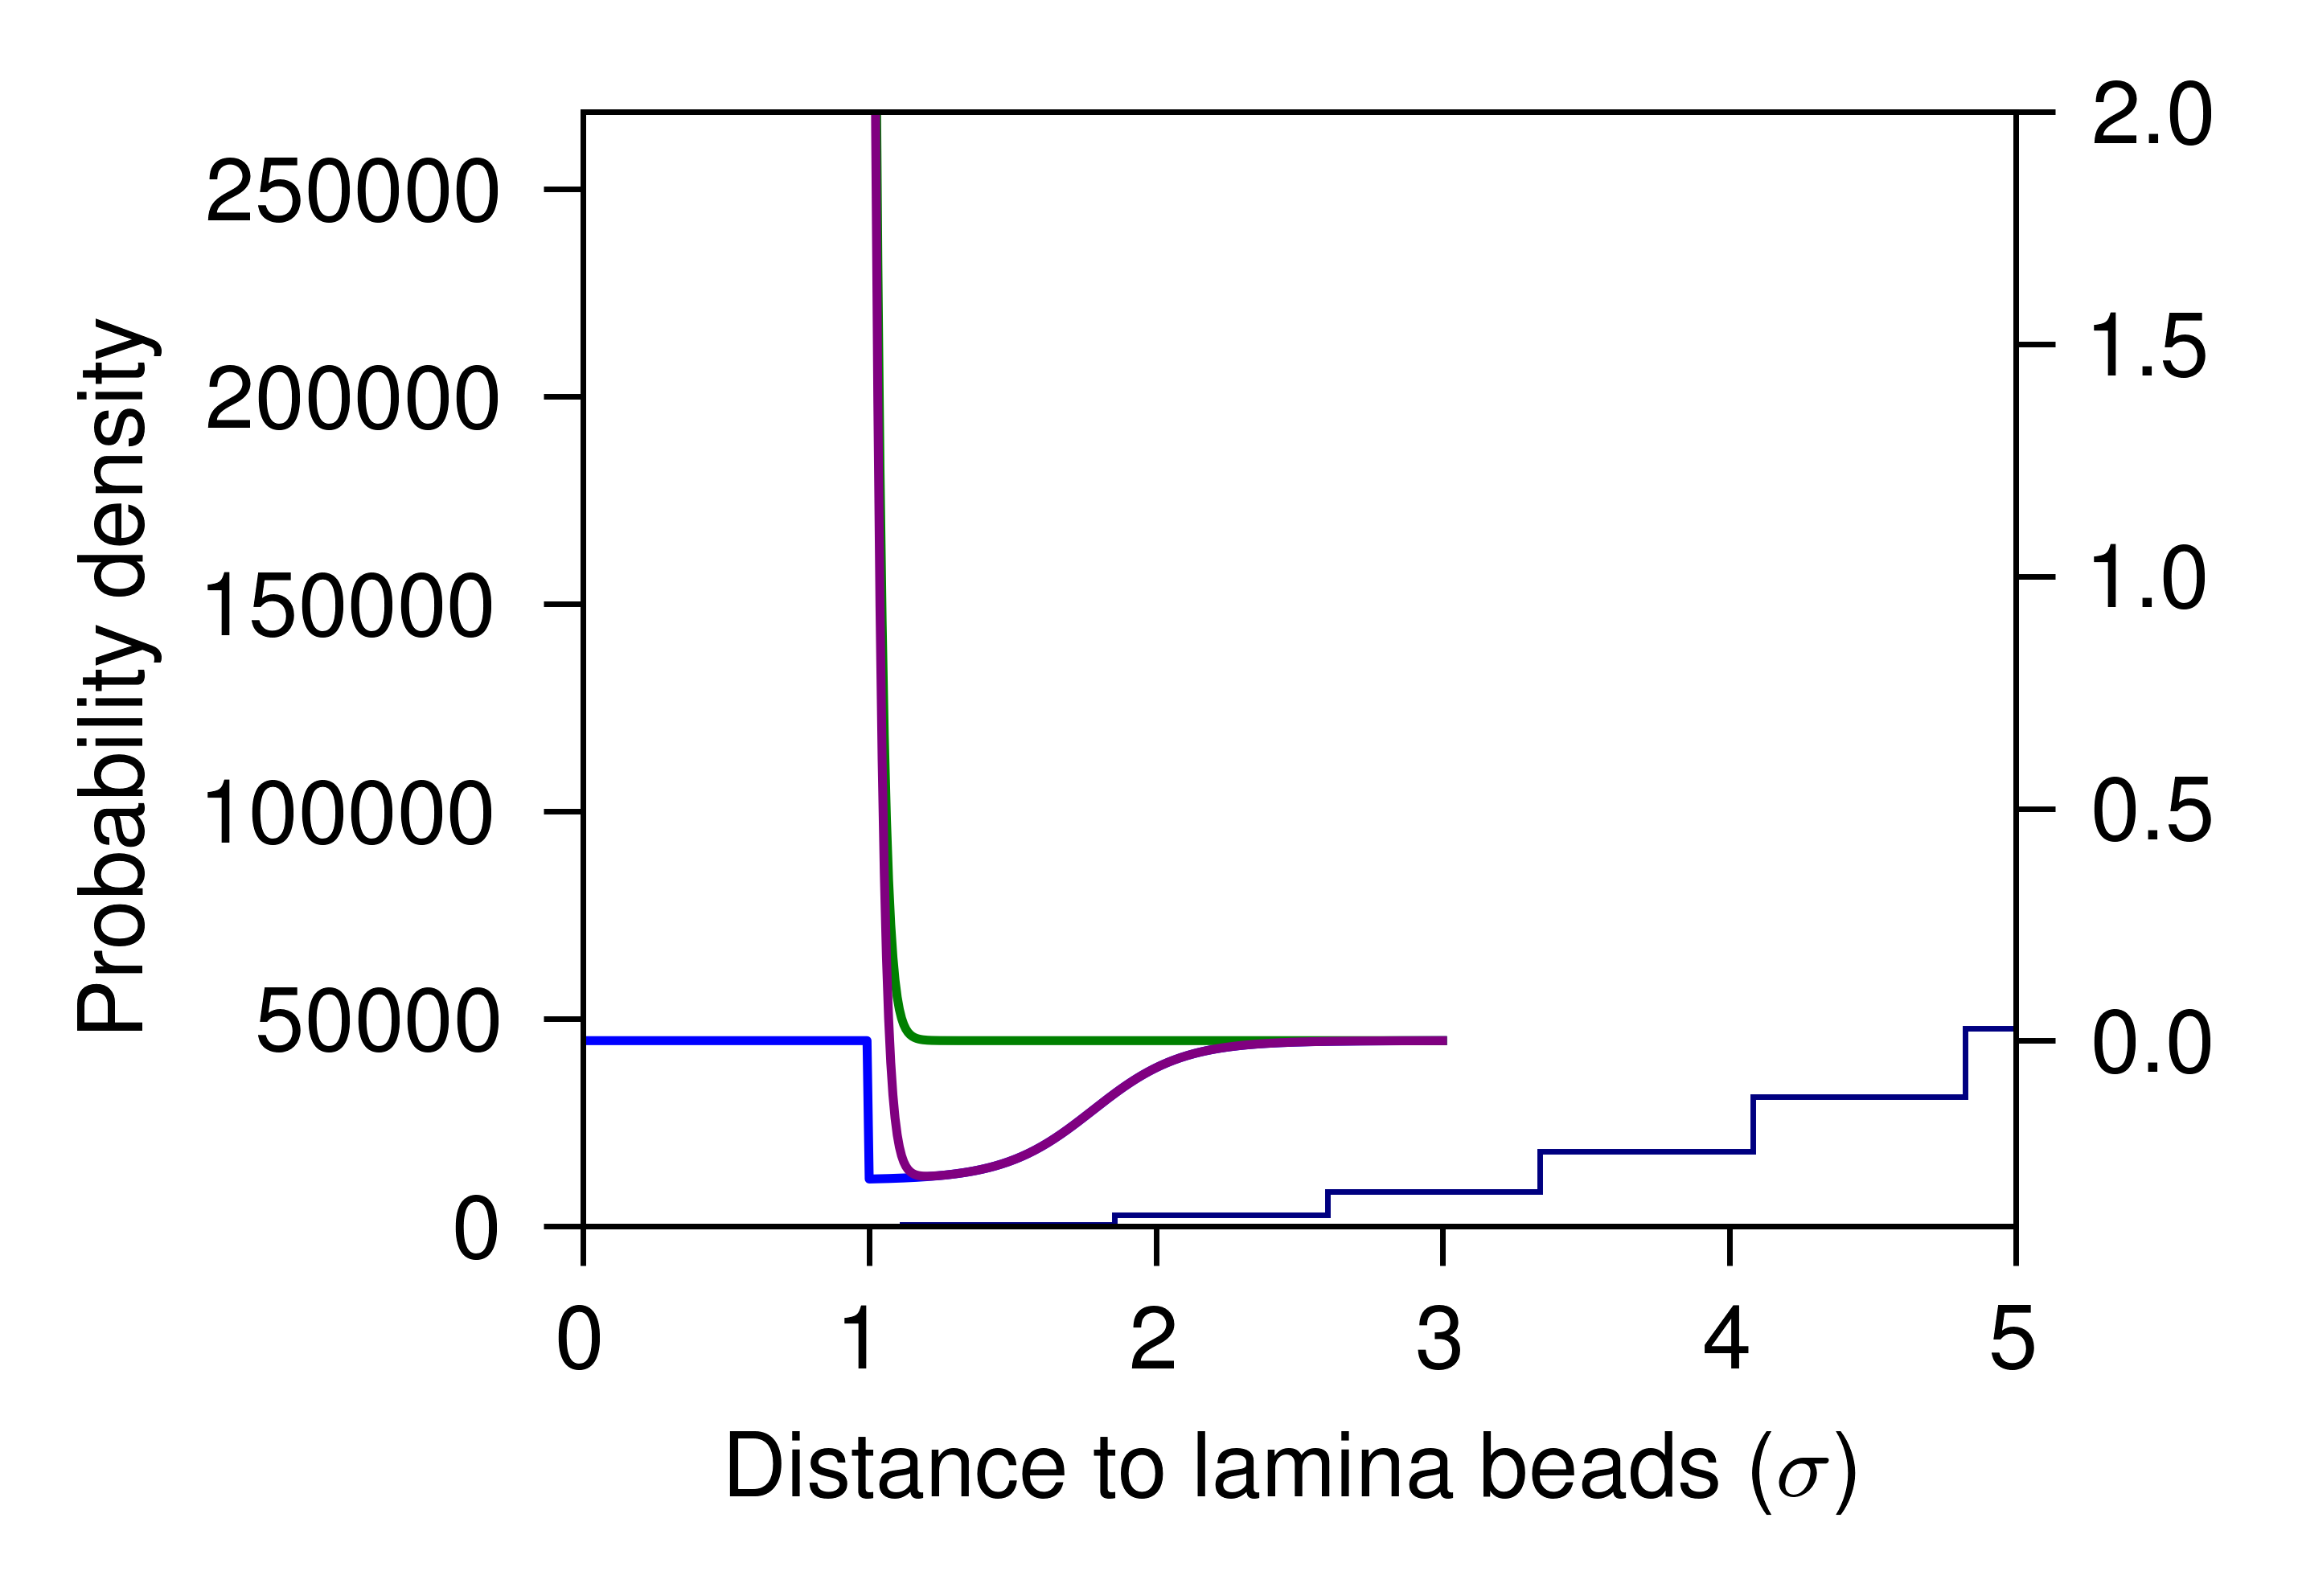

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

ax.hist(
    distances_to_lamina.flatten(),
    bins=50,
    # density=True,
    histtype="step",
)

ylim = ax.get_ylim()

# ax.vlines(NUCLEOLI_RADIUS, ylim[0], ylim[1], color="red", label="nucleolus radius")
# ax.vlines(NUCLEUS_RADIUS, ylim[0], ylim[1], color="black", label="nucleus radius")

ax.set_xlabel(r"Distance to lamina beads ($\sigma$)")
ax.set_ylabel("Probability density")
# ax.legend(loc="upper right", frameon=False)  

ax2 = ax.twinx()
r = np.linspace(0, 3, 400)

lamina_contact = contact(r, mu=3.22, rc=1.78, lim=1.0, epsilon=-0.3)
lamina_excl = tanh_exclusion(r, epsilon=1, Ecut=20, r0=0.93, k_rep=21.94)
# nucleolus_excl = nuclear_body_exclusion(
#     r, epsilon=1, Ecut=20, r0=0.93, k_rep=21.94, nb_radius=NUCLEOLI_RADIUS
# )

ax2.plot(r, lamina_contact, color="blue", label="lamina contact")
ax2.plot(r, lamina_excl, color="green", label="lamina exclusion")
ax2.plot(r, lamina_excl+lamina_contact, color="purple", label="total lamina potential")

ax.set_ylim(ylim[0], ylim[1])

ax.set_xlim(0, 5)
ax2.set_ylim(-0.4, 2)

## chr1


In [2]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 96
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/7_analysis/energies/data"

In [3]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [4]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [5]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [6]:
# for testing the figures:
# mpl.rcParams["figure.dpi"] = 300

### Comparing IC


In [15]:
IC = {}
types = {}

columns = [
    "step",
    "FENE",
    "angles",
    "self_avoidance",
    "types",
    "IC",
    "nucleolus",
    "nucleolus_exclusion",
    "spherical_confinement",
    "conic_confinement",
    "lamina",
]

col_to_exclude = {
    "nucleolus": ["lamina"],
    "lamina": ["nucleolus"],
    "complete": [],
    "control": ["nucleolus", "lamina"],
}

for condition in conditions:
    IC[condition] = []
    types[condition] = []

    for replica in range(1, NUM_REPLICAS + 1):

        df = pandas.read_csv(
            f"/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/{condition}/{replica}/energyComponents.txt",
            delimiter=",",
            skiprows=1,
            names=[
                x
                for x in columns
                if x not in col_to_exclude[condition]
            ],
        )
        IC[condition].extend(df["IC"].to_numpy())
        types[condition].extend(df["types"].to_numpy())

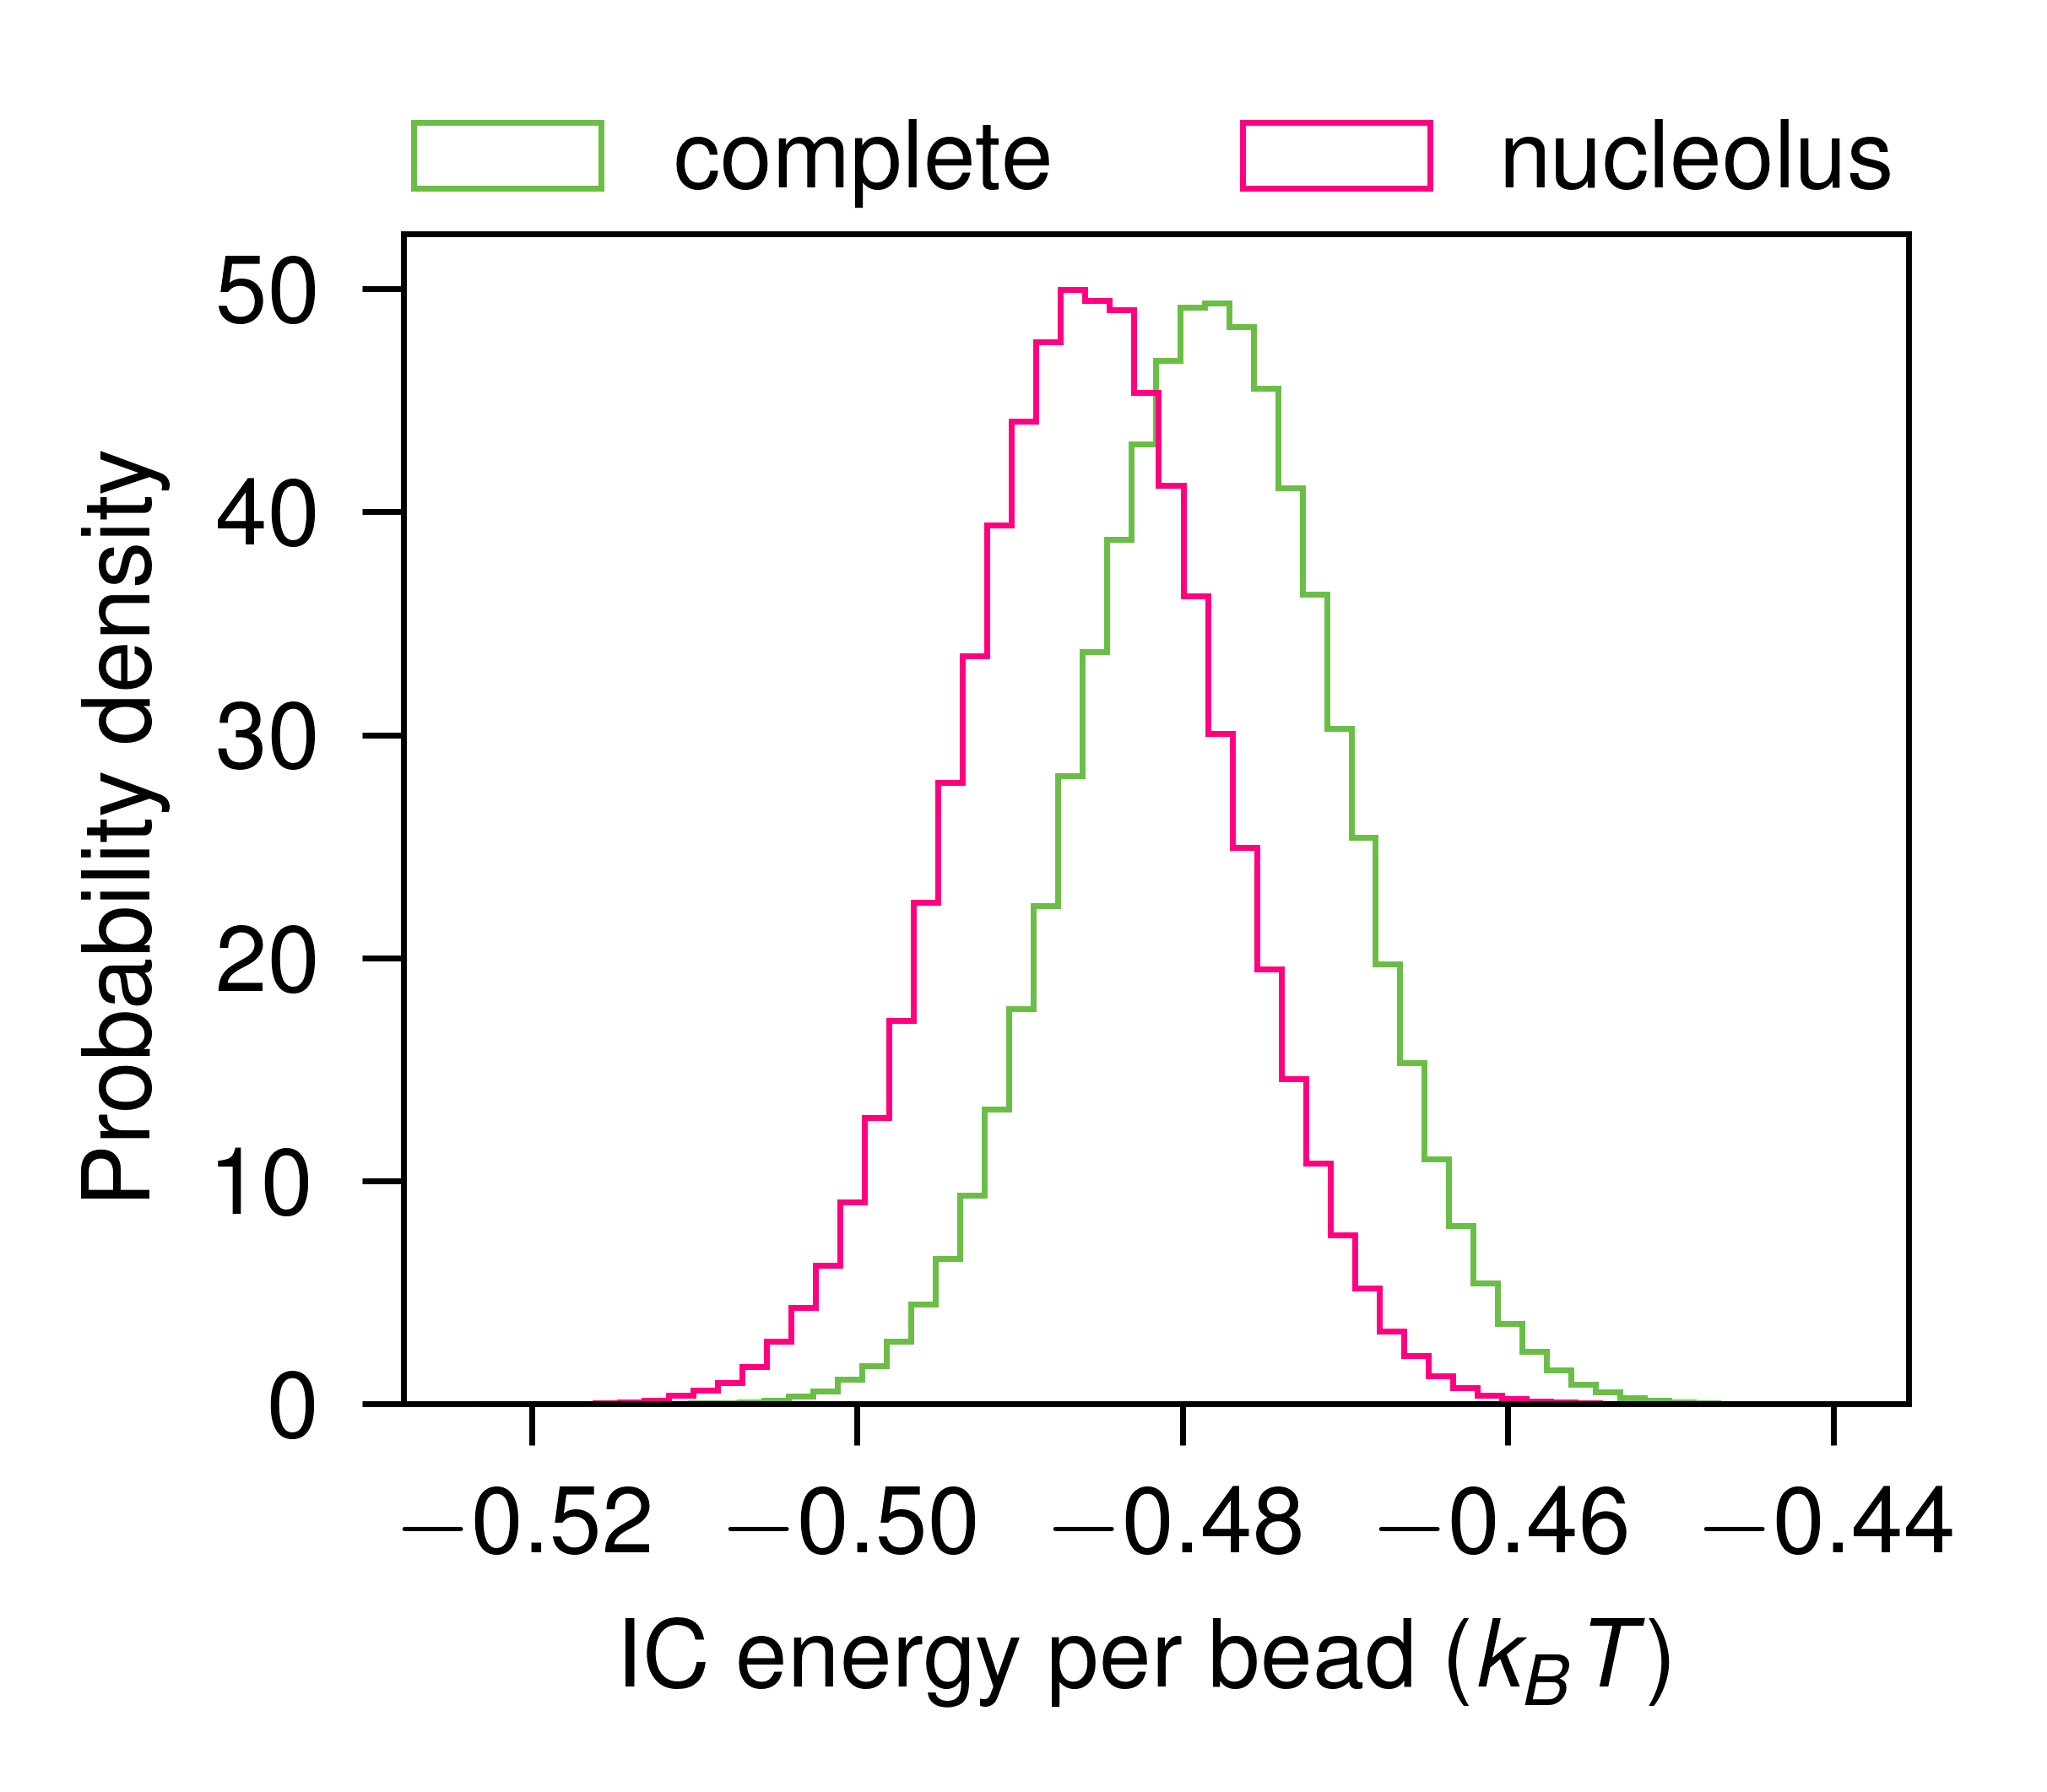

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in IC.keys():
    ax.hist(
        np.array(IC[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"IC energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

In [9]:
for condition in IC.keys():
    print(f"{condition}: mean={np.mean(IC[condition]) / NUM_BEADS:.3f}, std={np.std(IC[condition]) / NUM_BEADS:.3f}")

complete: mean=-0.478, std=0.008
nucleolus: mean=-0.486, std=0.008


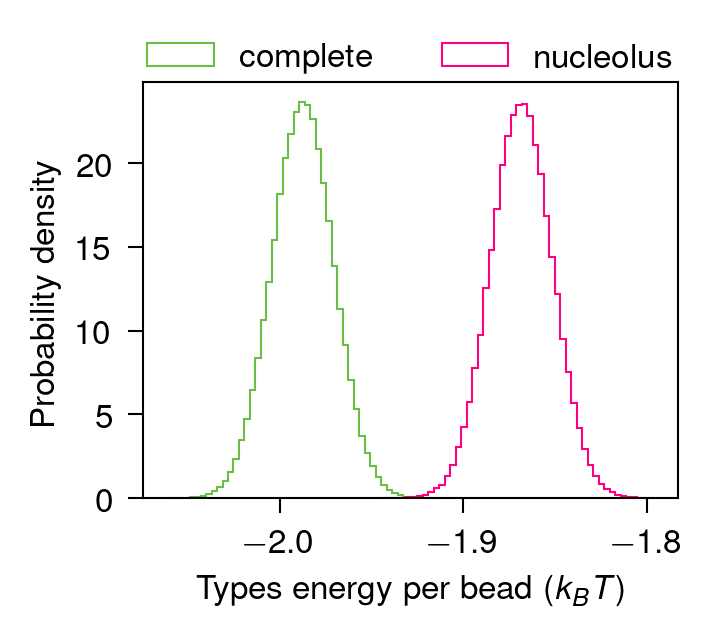

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in types.keys():
    ax.hist(
        np.array(types[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"Types energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

### Aggregate energy data


In [22]:
energies = {}
for condition in conditions:
    energies[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/contact-energies-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in energies[condition]:
                    energies[condition][key] = np.array([])
                energies[condition][key] = np.concatenate(
                    (
                        energies[condition][key],
                        f[key][()],
                    ),
                    axis=0,
                )
            energies[condition]["all"] = np.sum(
                np.array(
                    [
                        energies[condition][k]
                        for k in energies[condition]
                        if k != "all"
                    ]
                ),
                axis=0,
            )

In [23]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "w"
) as f:
    for condition in energies.keys():
        grp = f.create_group(condition)
        for key in energies[condition].keys():
            grp.create_dataset(key, data=energies[condition][key])

### Plotting contact energies


In [6]:
energies = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "r"
) as f:
    for condition in f.keys():
        energies[condition] = {}
        for key in f[condition].keys():
            energies[condition][key] = (
                f[condition][key][()] / NUM_BEADS
            )

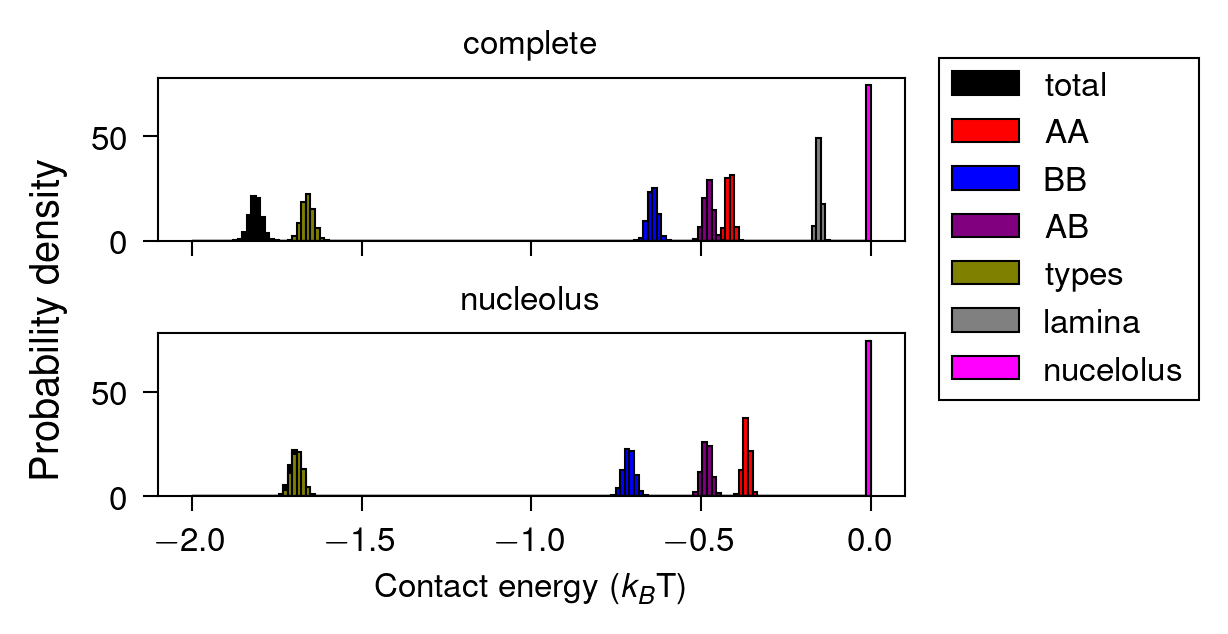

In [17]:
fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

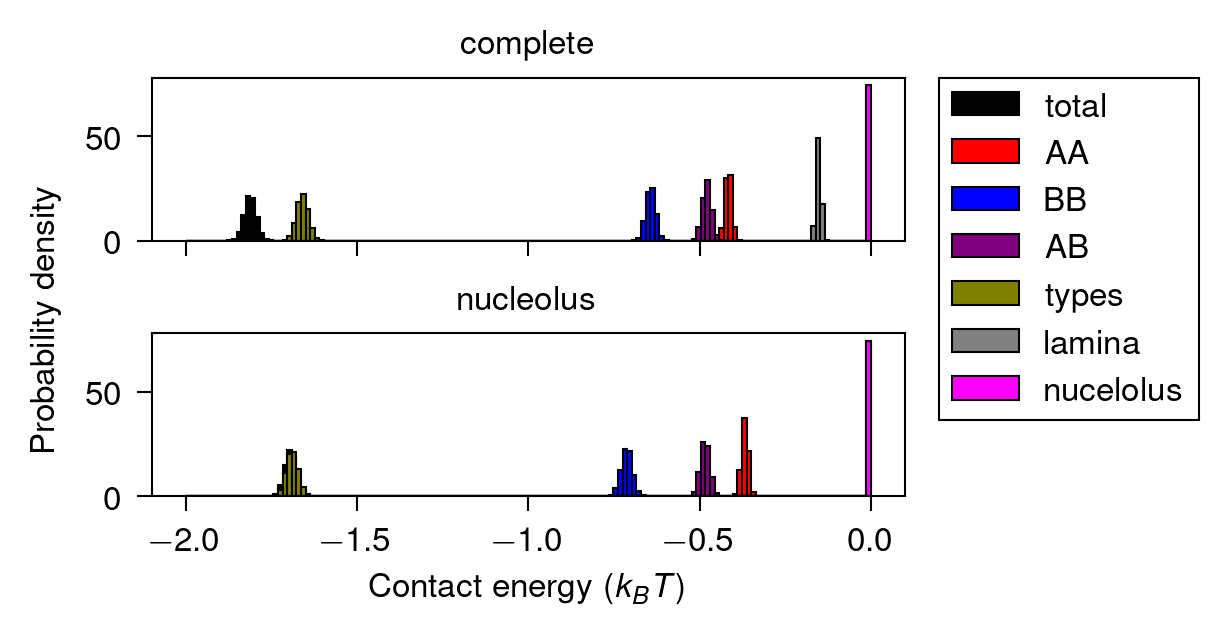

In [18]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

fig, ax = plt.subplots(
    len(chosen_conditions),
    1,
    figsize=(
        3,
        1 * len(chosen_conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(chosen_conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density", fontsize=8)
ax[-1].set_xlabel("Contact energy ($k_BT$)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.925),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

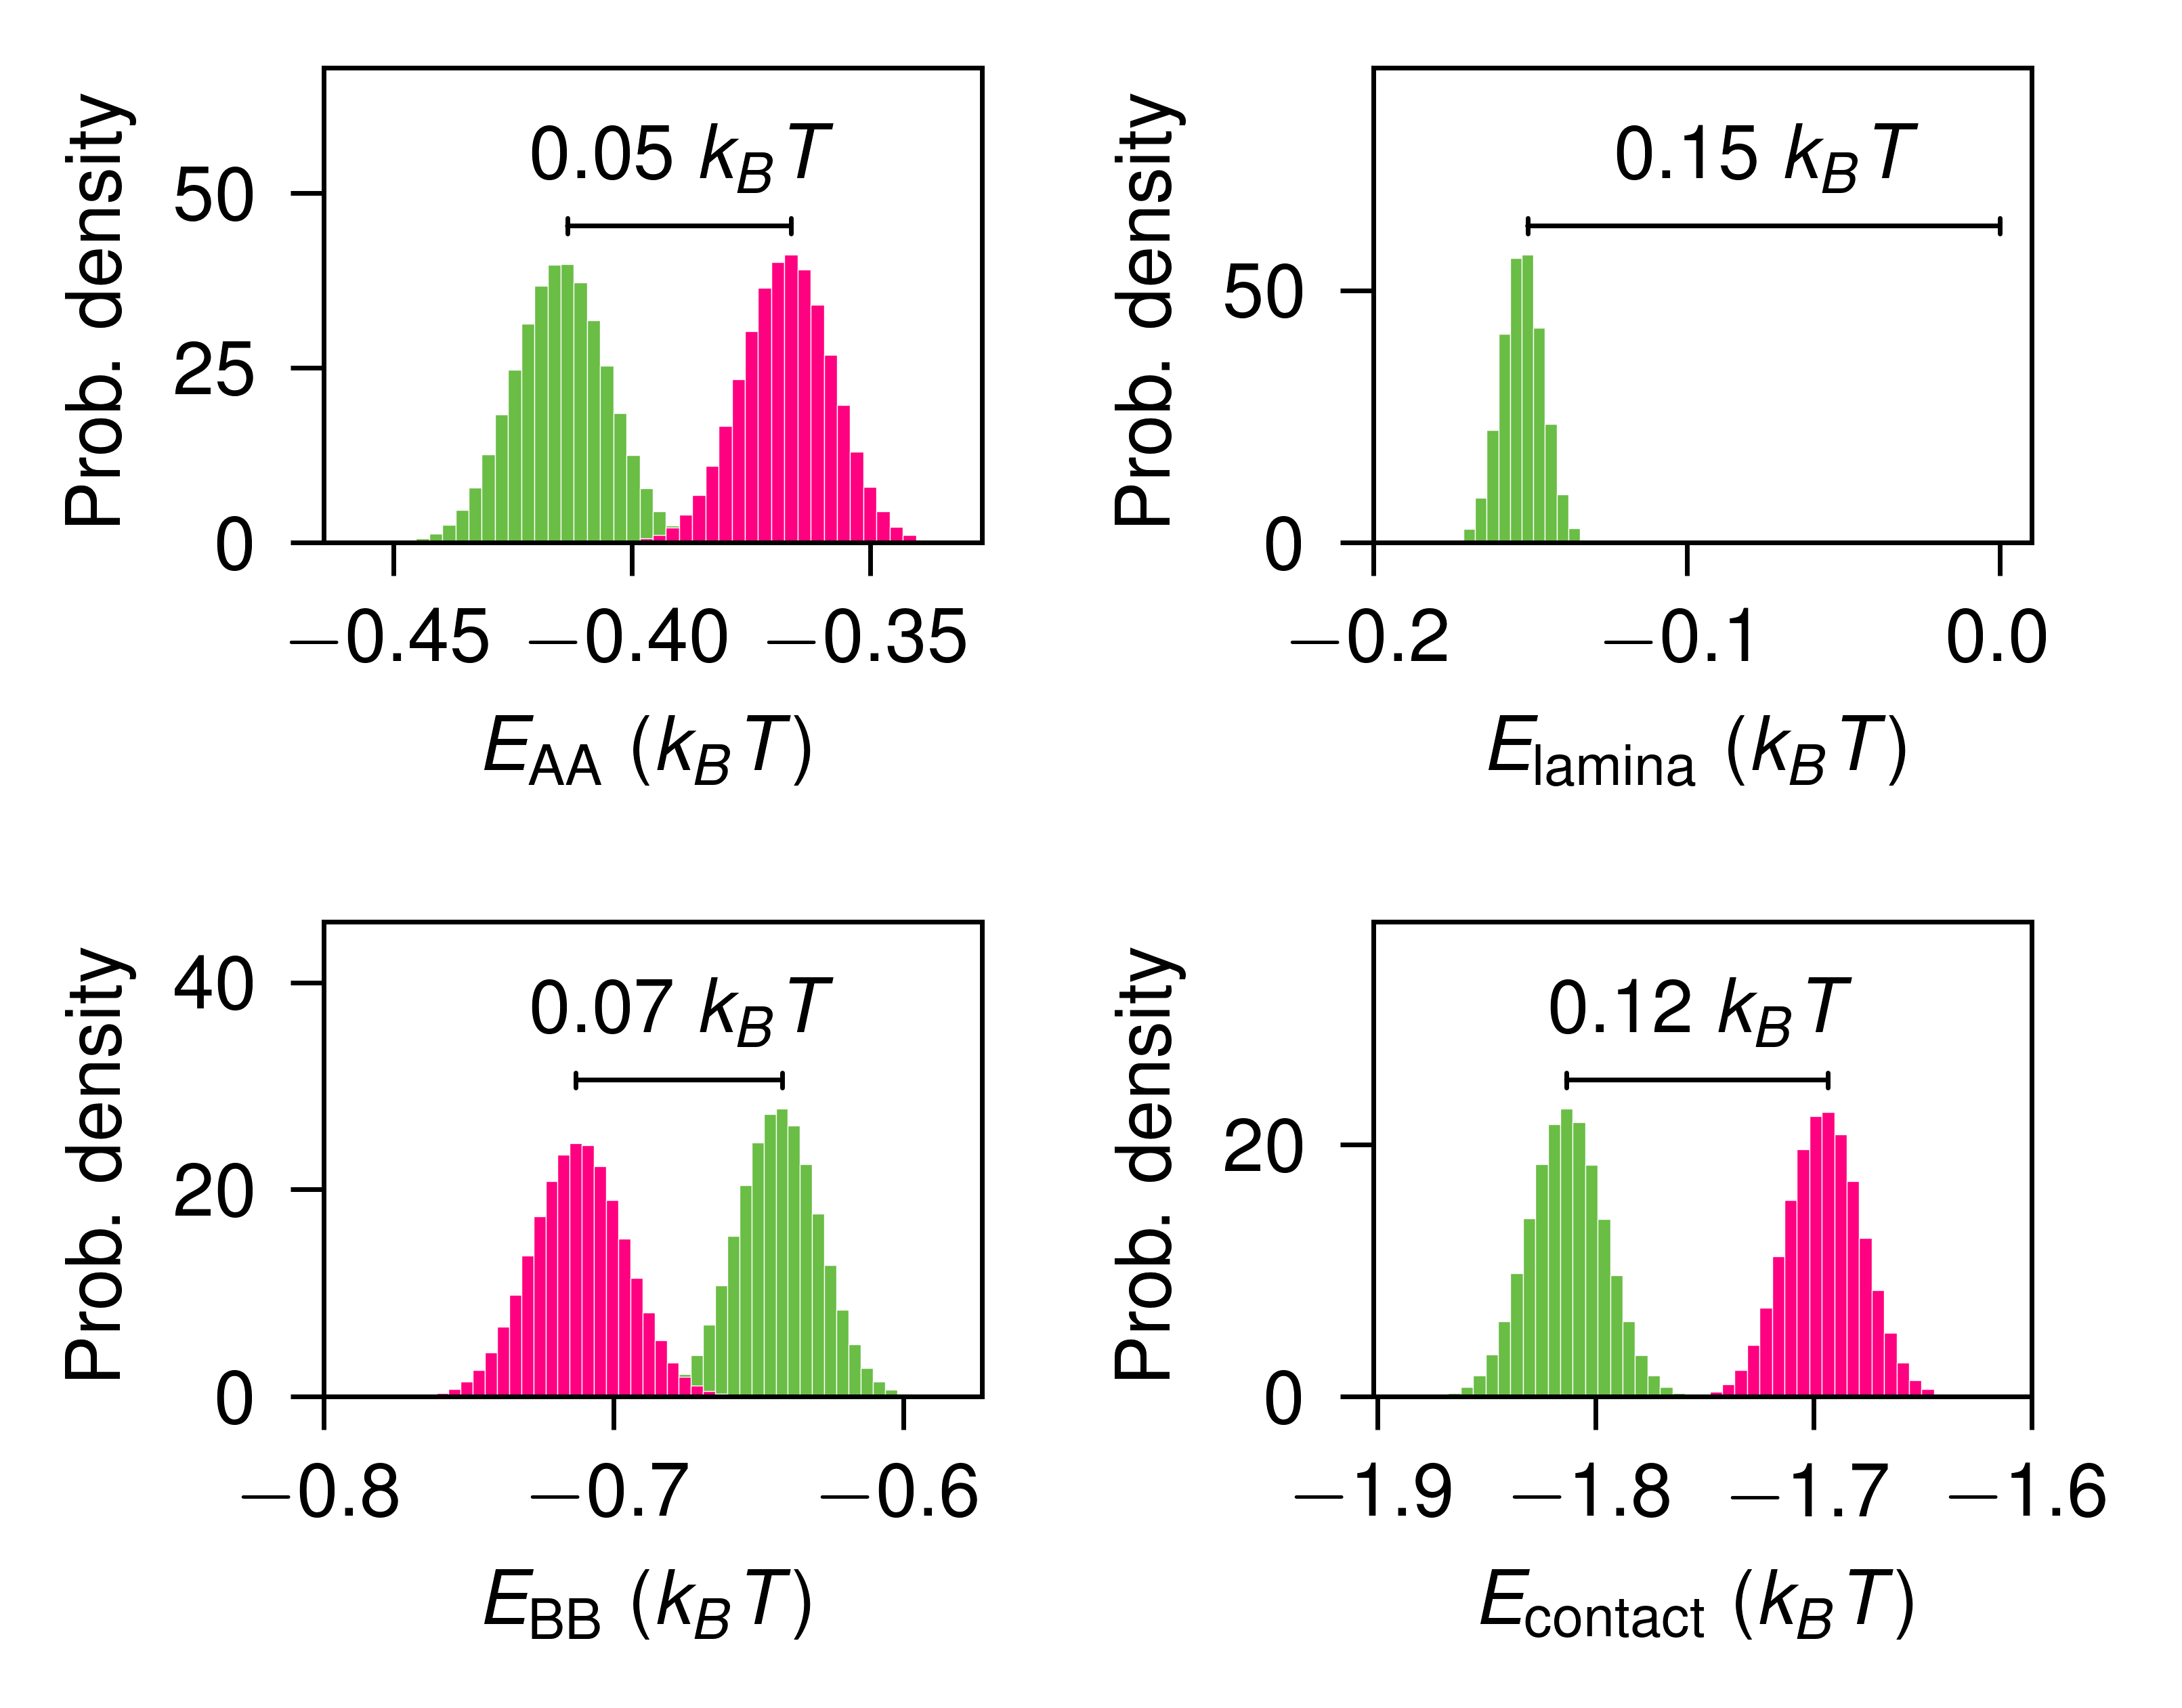

In [25]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = [
    "AA", 
    # "AB", 
    "BB", 
    "lamina", 
    # "nucleolus", 
    "all",
]
colors = [
    "red", 
    "purple", 
    "blue", 
    "gray", 
    "magenta", 
    "black",
]
xticks = [
    [-0.45, -0.40, -0.35],
    [-0.8, -0.7, -0.6],
    [-0.2, -0.1, 0],
    [-1.9, -1.8, -1.7, -1.6],
]

fig, ax = plt.subplots(
    len(labels) // 2,
    2,
    figsize=(
        3.2,
        2.5,
    ),
    # constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 26

ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            density=True,
        )
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
                edgecolor="white",
                linewidth=0.1,
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50 / NUM_BEADS

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = 1.1 * max(ymax)

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        f"${(energy_diff):.2f}$ $k_BT$" if energy_diff >= 0.01 else f"${(energy_diff):.3f}$ $k_BT$",
        # f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax[i].set_ylim(bottom=0, top=annot_y * 1.5)
    ax[i].set_xlim(vmin, vmax)
    ax[i].set_ylabel("Prob. density", fontsize=8)
    # ax[i].set_xlabel("Energy per bead ($k_BT$)")
    ax[i].set_xlabel(
        f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$ ($k_BT$)"
    )
    ax[i].set_xticks(xticks[i])
    # ax[i].set_title(
    #     f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    # )

    # formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    # formatter.set_scientific(True)
    # formatter.set_powerlimits((-1, 1))
    # ax[i].yaxis.set_major_formatter(formatter)

    # formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    # formatter.set_scientific(True)
    # formatter.set_powerlimits((-3, 1))
    # ax[i].xaxis.set_major_formatter(formatter)

# ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[-2].set_xlabel("Energy per bead ($k_BT$)",)

# handles, labels = ax[0].get_legend_handles_labels()

# fig.suptitle("chr1", fontsize=10)
fig.tight_layout(pad=0.8, w_pad=1.8, h_pad=1.8)
fig.savefig("fig-energy-comparison-chr1-complete-box.pdf")

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )

In [19]:
plt.rcParams["text.latex.preamble"] += r"\usepackage{xfrac}"

In [20]:
plt.rcParams["text.latex.preamble"]

'\\usepackage{amsmath} \\PassOptionsToPackage{scaled}{helvet} \\usepackage[helvet]{sfmath} \\renewcommand{\\familydefault}{\\sfdefault}\\usepackage{nicefrac}\\usepackage{xfrac}'

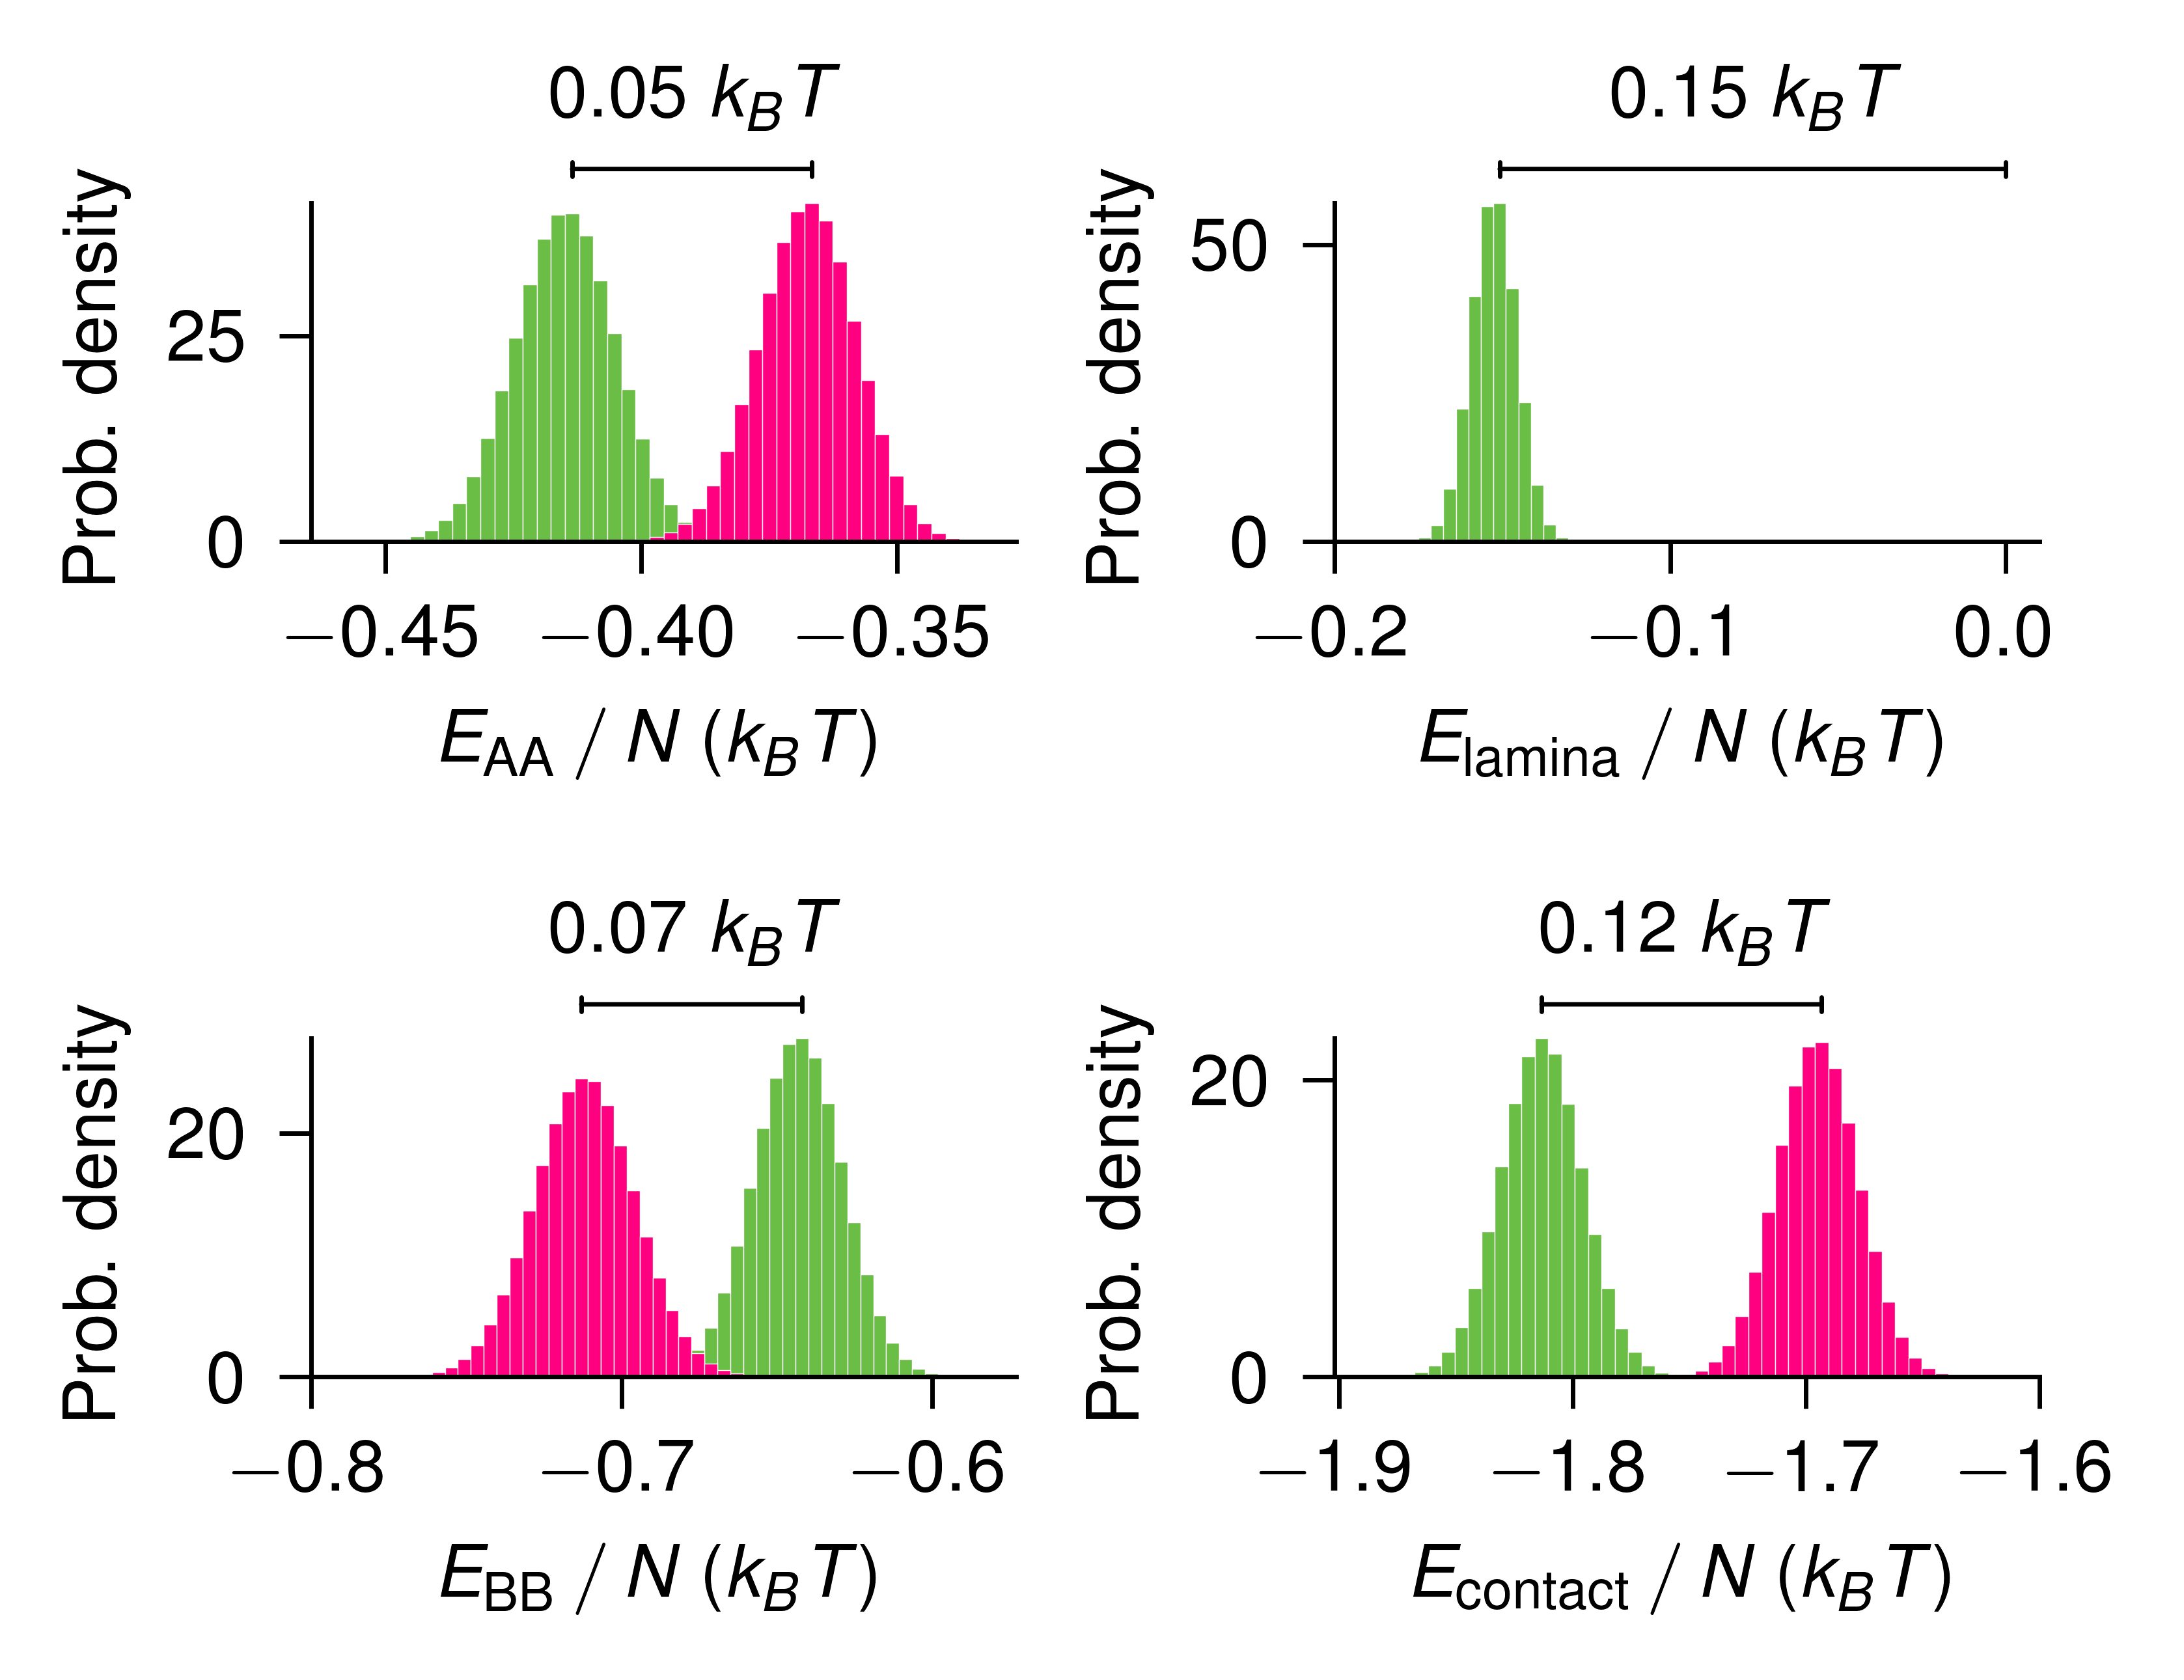

In [29]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = [
    "AA",
    # "AB",
    "BB",
    "lamina",
    # "nucleolus",
    "all",
]
colors = [
    "red",
    "purple",
    "blue",
    "gray",
    "magenta",
    "black",
]
xticks = [
    [-0.45, -0.40, -0.35],
    [-0.8, -0.7, -0.6],
    [-0.2, -0.1, 0],
    [-1.9, -1.8, -1.7, -1.6],
]

fig, ax = plt.subplots(
    len(labels) // 2,
    2,
    figsize=(
        3.2,
        2.5,
    ),
    # constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 26

ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            density=True,
        )
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
                edgecolor="white",
                linewidth=0.1,
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50 / NUM_BEADS

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = 1.1 * max(ymax)

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
        annotation_clip=False,
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        (
            f"${(energy_diff):.2f}$ $k_BT$"
            if energy_diff >= 0.01
            else f"${(energy_diff):.3f}$ $k_BT$"
        ),
        # f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax[i].set_ylim(bottom=0, top=max(ymax))
    ax[i].set_xlim(vmin, vmax)
    ax[i].set_ylabel("Prob. density", fontsize=8)
    # ax[i].set_xlabel("Energy per bead ($k_BT$)")
    ax[i].set_xlabel(
        rf"$E_{{\mathrm{{{label if label != 'all' else 'contact'}}}}} \,/\,  N$ ($k_B T$)"
    )
    ax[i].set_xticks(xticks[i])
    ax[i].spines[["right", "top"]].set_visible(False)
    # ax[i].set_title(
    #     f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    # )

    # formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    # formatter.set_scientific(True)
    # formatter.set_powerlimits((-1, 1))
    # ax[i].yaxis.set_major_formatter(formatter)

    # formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    # formatter.set_scientific(True)
    # formatter.set_powerlimits((-3, 1))
    # ax[i].xaxis.set_major_formatter(formatter)

# ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[-2].set_xlabel("Energy per bead ($k_BT$)",)

# handles, labels = ax[0].get_legend_handles_labels()

# fig.suptitle("chr1", fontsize=10)
fig.tight_layout(pad=0.2, w_pad=1.0, h_pad=1.0)
fig.savefig("fig-energy-comparison-chr1.pdf")

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )

0.13047395833333333
0.21242604166666668
0.11627291666666667
0.11351979166666666


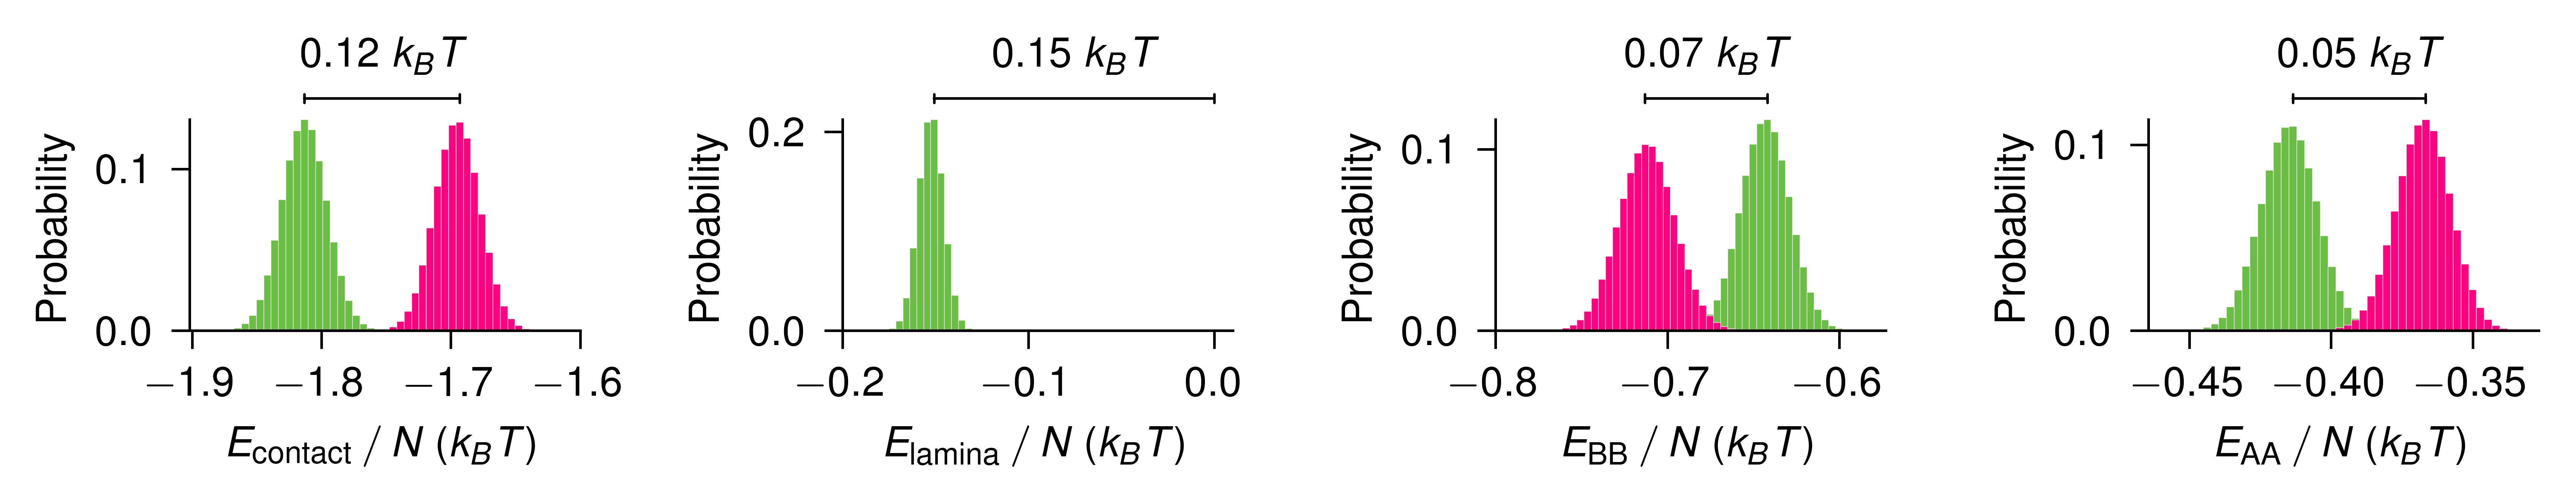

In [39]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = [
    "all",
    "lamina",
    "BB",
    "AA",
    # "AB",
    # "nucleolus",
]
colors = [
    "red",
    "purple",
    "blue",
    "gray",
    "magenta",
    "black",
]
xticks = [
    [-1.9, -1.8, -1.7, -1.6],
    [-0.2, -0.1, 0],
    [-0.8, -0.7, -0.6],
    [-0.45, -0.40, -0.35],
]
yticks = [
    [0, 0.1, 0.2],
    [0, 0.1, 0.2],
    [0, 0.1, 0.2],
    [0, 0.1, 0.2],
]

fig, ax = plt.subplots(
    1,
    4,
    figsize=(
        7,
        1.5,
    ),
    # constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 26

# ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            # density=True,
        )
        hist = hist / np.sum(hist)
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
                edgecolor="white",
                linewidth=0.1,
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50 / NUM_BEADS

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = max(ymax) * 1.1

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
        annotation_clip=False,
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        (
            f"${(energy_diff):.2f}$ $k_BT$"
            if energy_diff >= 0.01
            else f"${(energy_diff):.3f}$ $k_BT$"
        ),
        # f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )
    print(max(ymax))
    ax[i].set_ylim(bottom=0, top=max(ymax))
    ax[i].set_xlim(vmin, vmax)
    # ax[i].set_xlabel("Energy per bead ($k_BT$)")
    ax[i].set_xlabel(
        rf"$E_{{\mathrm{{{label if label != 'all' else 'contact'}}}}} \,/\,  N$ ($k_B T$)"
    )
    ax[i].set_xticks(xticks[i])
    # ax[i].set_yticks(yticks[i])
    ax[i].spines[["right", "top"]].set_visible(False)
    ax[i].set_ylabel("Probability", fontsize=8)
    # ax[i].set_title(
    #     f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    # )

    # formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    # formatter.set_scientific(True)
    # formatter.set_powerlimits((-1, 1))
    # ax[i].yaxis.set_major_formatter(formatter)

    # formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    # formatter.set_scientific(True)
    # formatter.set_powerlimits((-3, 1))
    # ax[i].xaxis.set_major_formatter(formatter)

# ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[-2].set_xlabel("Energy per bead ($k_BT$)",)

# handles, labels = ax[0].get_legend_handles_labels()

# fig.suptitle("chr1", fontsize=10)
fig.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
fig.savefig("fig-energy-comparison-chr1-one-row-paper-order.pdf")

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )

## chr1 | ∆lam = 1.5 & undivided


In [26]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 32
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/9_analysis/energies/data"

In [21]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [22]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [23]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [24]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

### Comparing IC


In [ ]:
IC = {}
types = {}

columns = [
    "step",
    "FENE",
    "angles",
    "self_avoidance",
    "types",
    "IC",
    "nucleolus",
    "nucleolus_exclusion",
    "spherical_confinement",
    "conic_confinement",
    "lamina",
]

col_to_exclude = {
    "nucleolus": ["lamina"],
    "lamina": ["nucleolus"],
    "complete": [],
    "control": ["nucleolus", "lamina"],
}

for condition in conditions:
    IC[condition] = []
    types[condition] = []

    for replica in range(1, NUM_REPLICAS + 1):

        df = pandas.read_csv(
            f"/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/3_sampling/{condition}/{replica}/energyComponents.txt",
            delimiter=",",
            skiprows=1,
            names=[
                x
                for x in columns
                if x not in col_to_exclude[condition]
            ],
        )
        IC[condition].extend(df["IC"].to_numpy())
        types[condition].extend(df["types"].to_numpy())

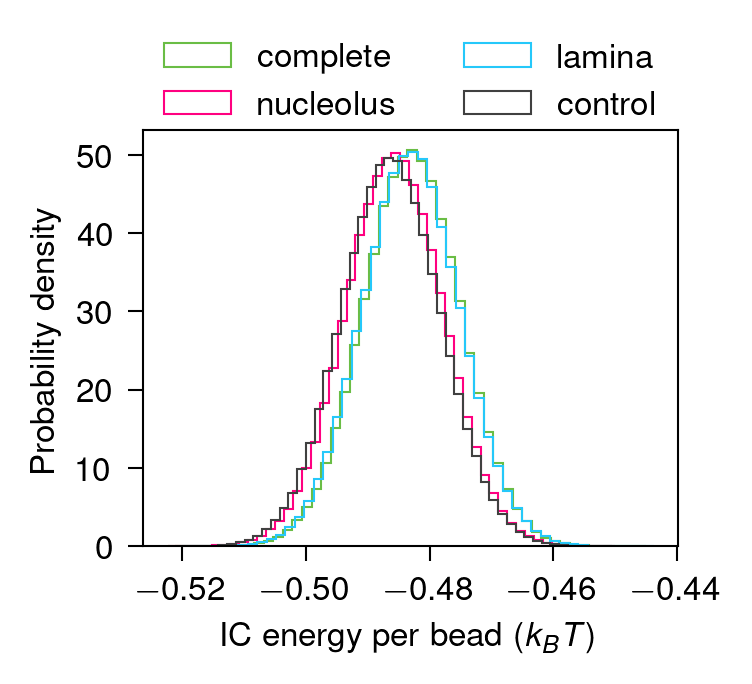

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in IC.keys():
    ax.hist(
        np.array(IC[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"IC energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

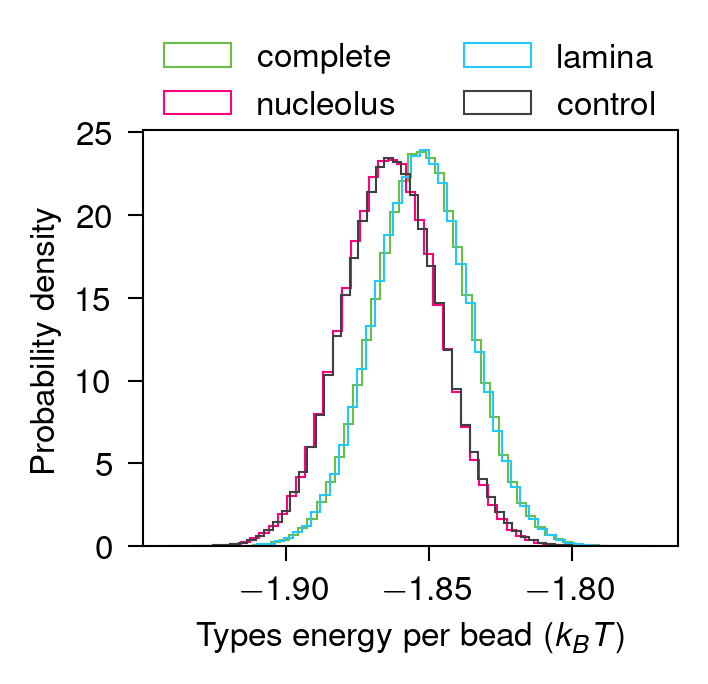

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in types.keys():
    ax.hist(
        np.array(types[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"Types energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

### Aggregate energy data


In [27]:
energies = {}
for condition in conditions:
    energies[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/contact-energies-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in energies[condition]:
                    energies[condition][key] = np.array([])
                energies[condition][key] = np.concatenate(
                    (
                        energies[condition][key],
                        f[key][()],
                    ),
                    axis=0,
                )
            energies[condition]["all"] = np.sum(
                np.array(
                    [
                        energies[condition][k]
                        for k in energies[condition]
                        if k != "all"
                    ]
                ),
                axis=0,
            )

In [28]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "w"
) as f:
    for condition in energies.keys():
        grp = f.create_group(condition)
        for key in energies[condition].keys():
            grp.create_dataset(key, data=energies[condition][key])

### Plotting contact energies


In [29]:
energies = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "r"
) as f:
    for condition in f.keys():
        energies[condition] = {}
        for key in f[condition].keys():
            energies[condition][key] = (
                f[condition][key][()] / NUM_BEADS
            )

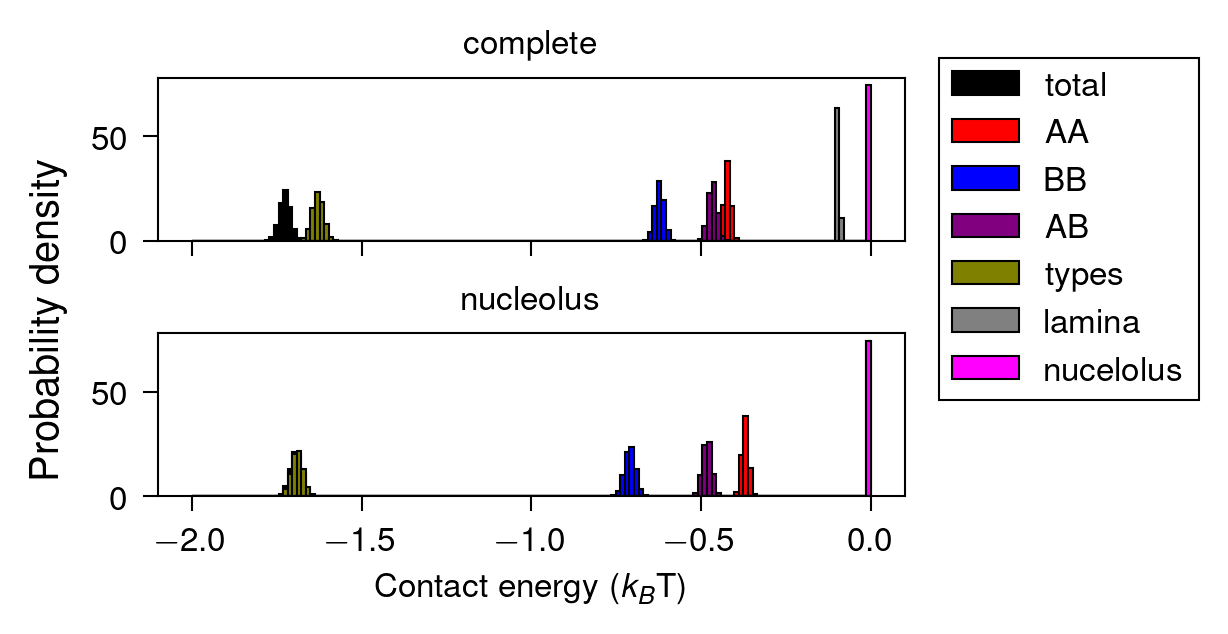

In [30]:
fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

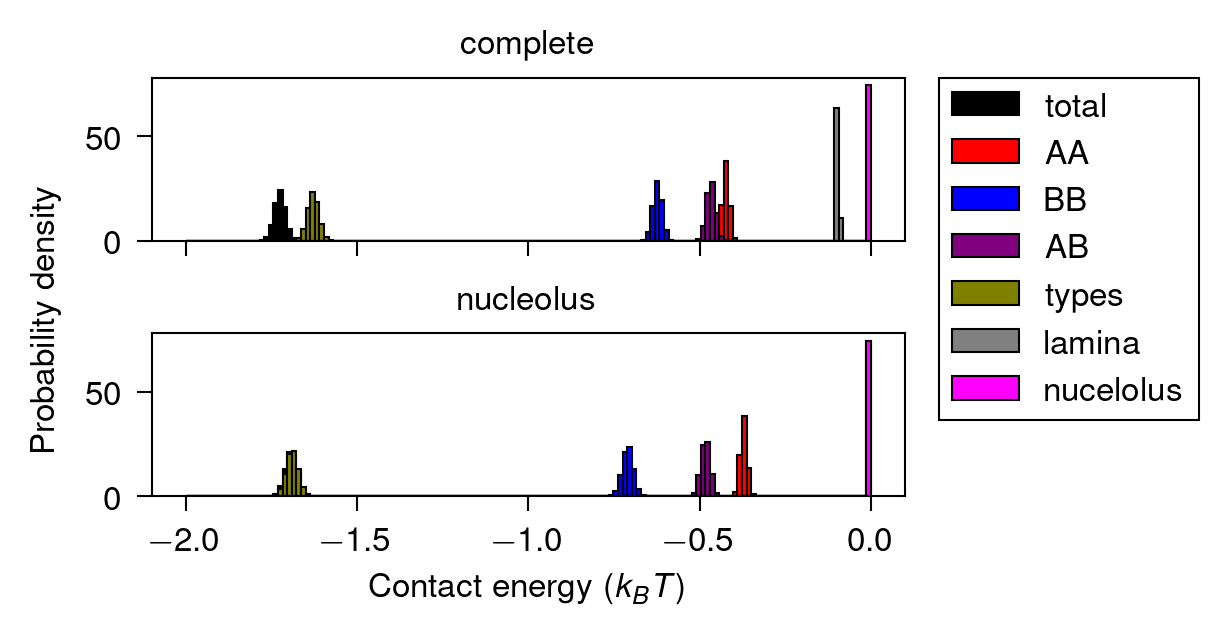

In [31]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

fig, ax = plt.subplots(
    len(chosen_conditions),
    1,
    figsize=(
        3,
        1 * len(chosen_conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(chosen_conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density", fontsize=8)
ax[-1].set_xlabel("Contact energy ($k_BT$)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.925),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

Text(0.5, 0.98, 'chr1')

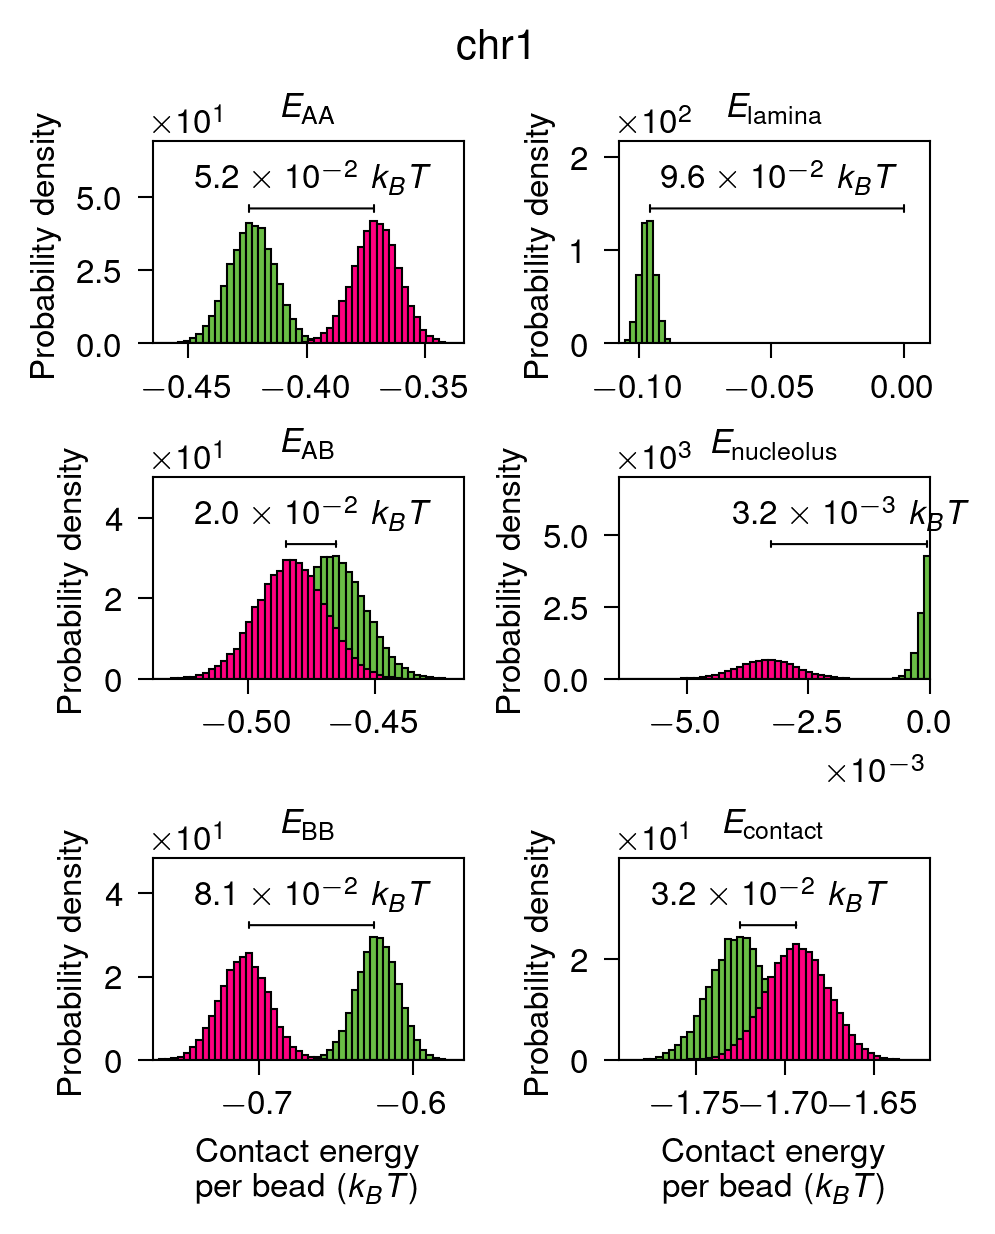

In [32]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = ["AA", "AB", "BB", "lamina", "nucleolus", "all"]
colors = ["red", "purple", "blue", "gray", "magenta", "black"]

fig, ax = plt.subplots(
    len(labels) // 2,
    2,
    figsize=(
        3.2,
        4.0,
    ),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 51

ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            density=True,
        )
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50 / NUM_BEADS

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = 1.1 * max(ymax)

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        # f"${int(energy_diff)}$ $k_BT$",
        f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax[i].set_title(
        f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    )
    ax[i].set_ylim(bottom=0, top=annot_y * 1.5)
    ax[i].set_xlim(vmin, vmax)
    ax[i].set_ylabel("Probability density", fontsize=8)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax[i].yaxis.set_major_formatter(formatter)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 1))
    ax[i].xaxis.set_major_formatter(formatter)

# ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
ax[-1].set_xlabel("Contact energy\nper bead ($k_BT$)",)
ax[2].set_xlabel("Contact energy\nper bead ($k_BT$)",)

# handles, labels = ax[0].get_legend_handles_labels()

fig.suptitle("chr1", fontsize=10)

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )

## chr17


In [33]:
conditions = ["complete", "nucleolus", "lamina", "control"]

NUM_REPLICAS = 32
NUM_BEADS = 1666
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/5_IMR-90_hg38_chr17/4_analysis/energies/data"

In [ ]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [ ]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [ ]:
title = {
    "complete": r"$\in\,\text{lamina}$",
    "nucleolus": r"$\notin\,\text{lamina}$",
}

In [ ]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

### Comparing IC

In [ ]:
IC = {}
types = {}

columns = [
    "step",
    "FENE",
    "angles",
    "self_avoidance",
    "types",
    "IC",
    "nucleolus",
    "nucleolus_exclusion",
    "spherical_confinement",
    "conic_confinement",
    "lamina",
]

col_to_exclude = {
    "nucleolus": ["lamina"],
    "lamina": ["nucleolus"],
    "complete": [],
    "control": ["nucleolus", "lamina"],
}

for condition in conditions:
    IC[condition] = []
    types[condition] = []

    for replica in range(1, NUM_REPLICAS + 1):

        df = pandas.read_csv(
            f"/scratch/mm146/Polarization/5_IMR-90_hg38_chr17/3_sampling/{condition}/{replica}/energyComponents.txt",
            delimiter=",",
            skiprows=1,
            names=[
                x
                for x in columns
                if x not in col_to_exclude[condition]
            ],
        )
        IC[condition].extend(df["IC"].to_numpy())
        types[condition].extend(df["types"].to_numpy())

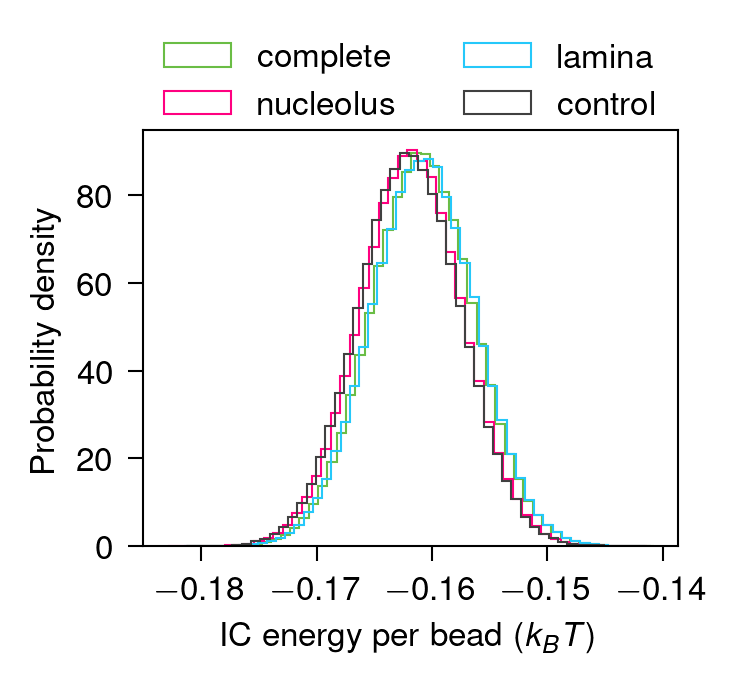

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in IC.keys():
    ax.hist(
        np.array(IC[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"IC energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

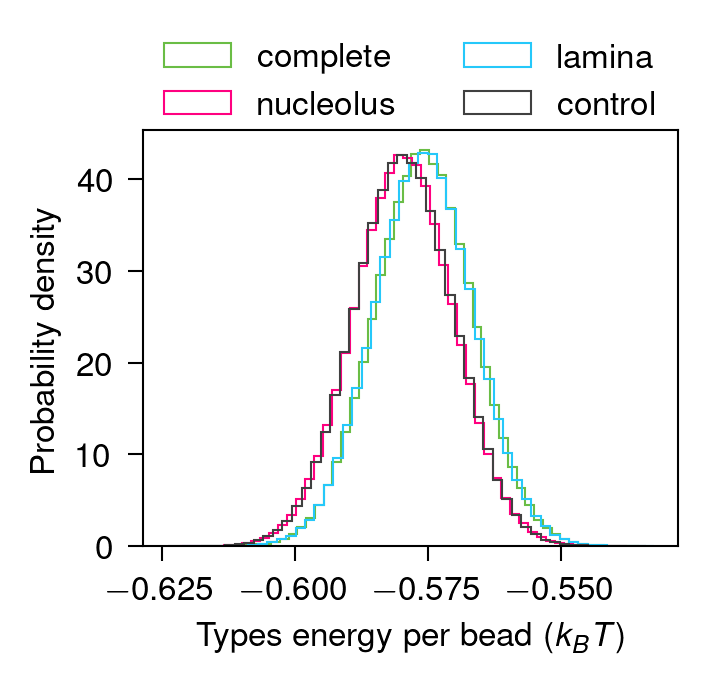

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in types.keys():
    ax.hist(
        np.array(types[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"Types energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

### Aggregate energy data

In [ ]:
energies = {}
for condition in conditions:
    energies[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/contact-energies-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in energies[condition]:
                    energies[condition][key] = np.array([])
                energies[condition][key] = np.concatenate(
                    (
                        energies[condition][key],
                        f[key][()],
                    ),
                    axis=0,
                )
            energies[condition]["all"] = np.sum(
                np.array(
                    [
                        energies[condition][k]
                        for k in energies[condition]
                        if k != "all"
                    ]
                ),
                axis=0,
            )

In [ ]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "w"
) as f:
    for condition in energies.keys():
        grp = f.create_group(condition)
        for key in energies[condition].keys():
            grp.create_dataset(key, data=energies[condition][key])

### Plotting contact energies

In [ ]:
energies = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "r"
) as f:
    for condition in f.keys():
        energies[condition] = {}
        for key in f[condition].keys():
            energies[condition][key] = (
                f[condition][key][()] / NUM_BEADS
            )

In [ ]:
fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

In [ ]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

fig, ax = plt.subplots(
    len(chosen_conditions),
    1,
    figsize=(
        3,
        1 * len(chosen_conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(chosen_conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density", fontsize=8)
ax[-1].set_xlabel("Contact energy ($k_BT$)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.925),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

Text(0.5, 0.98, 'chr17')

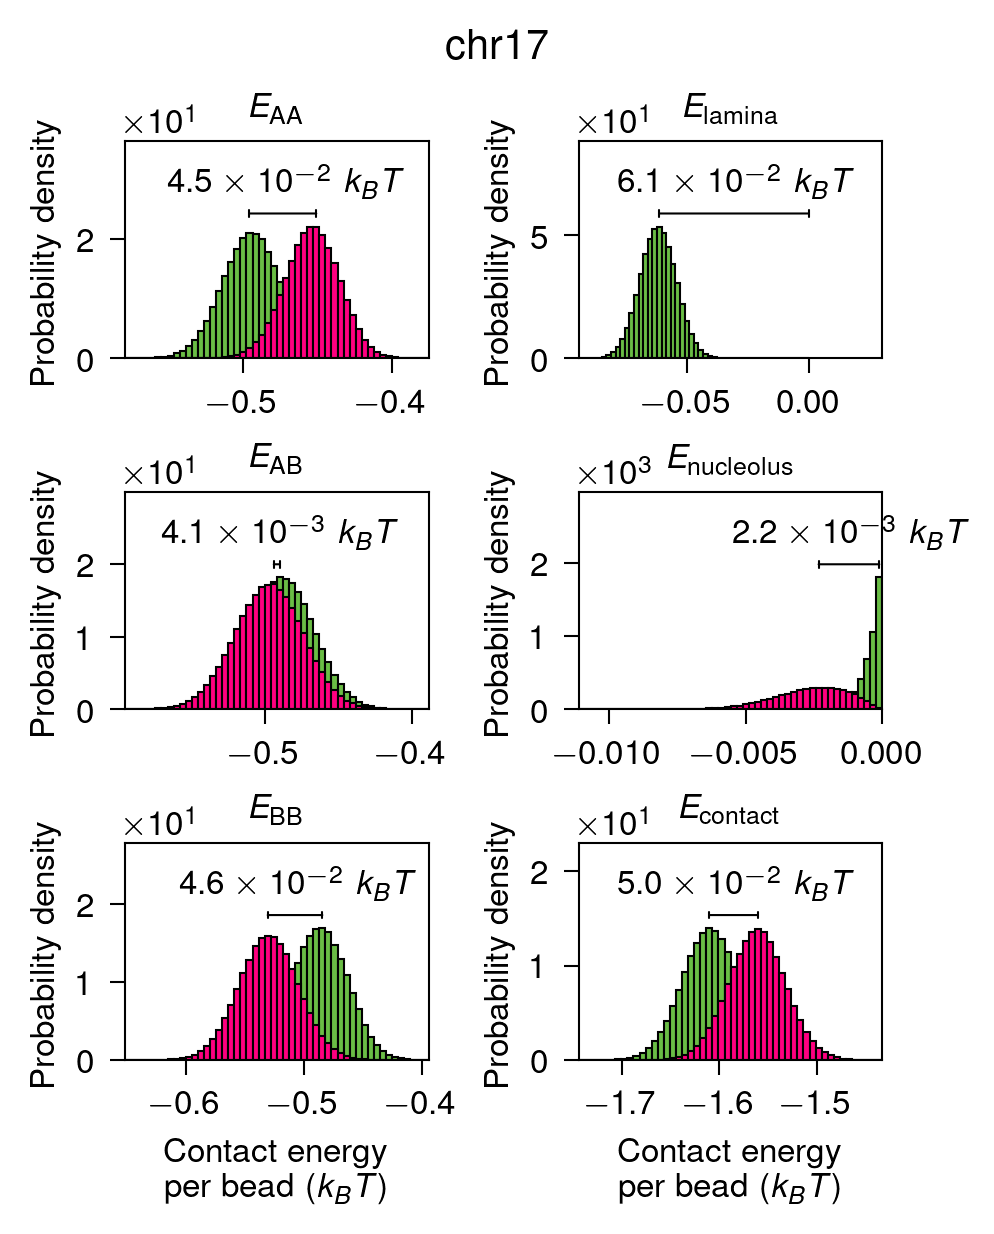

In [ ]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = ["AA", "AB", "BB", "lamina", "nucleolus", "all"]
colors = ["red", "purple", "blue", "gray", "magenta", "black"]

fig, ax = plt.subplots(
    len(labels) // 2,
    2,
    figsize=(
        3.2,
        4.0,
    ),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 51

ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            density=True,
        )
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50 / NUM_BEADS

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = 1.1 * max(ymax)

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        # f"${int(energy_diff)}$ $k_BT$",
        f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax[i].set_title(
        f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    )
    ax[i].set_ylim(bottom=0, top=annot_y * 1.5)
    ax[i].set_xlim(vmin, vmax)
    ax[i].set_ylabel("Probability density", fontsize=8)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax[i].yaxis.set_major_formatter(formatter)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 1))
    ax[i].xaxis.set_major_formatter(formatter)

# ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
ax[-1].set_xlabel("Contact energy\nper bead ($k_BT$)",)
ax[2].set_xlabel("Contact energy\nper bead ($k_BT$)",)

# handles, labels = ax[0].get_legend_handles_labels()

fig.suptitle("chr17", fontsize=10)

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )